# Восстановление сети Петри и параметров временных распределений

Продолжение `stochastic_petri_net.ipynb`: та же сеть с одним токеном,
те же распределения, выбор перехода по вероятности и независимая потеря наблюдения.
Ноутбук сам генерирует данные; запускать исходный ноутбук или загружать его CSV не нужно.

**Цель:** оценить вероятности выбора и параметры времени по журналу и проверить,
как качество восстановления зависит от количества сгенерированных трасс.

Семейства распределений для пар состояний предполагаются известными.
Истинные численные параметры используются только при генерации и оценке ошибок.
Выбор семейства распределения по данным здесь не исследуется.

Оцениваем две модели: наивную (только завершённые интервалы) и модель с учётом
правого цензурирования. Структуру дополнительно восстанавливаем существующим
Inductive Miner из PM4Py и проверяем на независимом логе.


In [1]:
import math
from collections import Counter
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from scipy.special import logsumexp, softmax
from IPython.display import display


## 1. Исходная модель и настройки эксперимента

Модель и генератор перенесены из исходного ноутбука. Времена храним в днях,
до округления timestamp. Число трасс означает число вошедших в исследование объектов,
включая цензурированные трассы.


In [2]:
PLACES = ["A", "B", "C", "D"]
START = "A"      # здесь лежит фишка в момент входа объекта в наблюдение
TERMINAL = "D"   # поглощающее состояние = «событие»

# dist = (тип, параметры); время в днях
TRANSITIONS = [
    dict(name="A→B", src="A", dst="B", p=0.7, dist=("exponential", {"mean": 2.0})),
    dict(name="A→C", src="A", dst="C", p=0.3, dist=("lognormal",   {"median": 5.0, "sigma": 0.5})),
    dict(name="B→A", src="B", dst="A", p=0.2, dist=("uniform",     {"low": 1.0, "high": 3.0})),
    dict(name="B→C", src="B", dst="C", p=0.5, dist=("gamma",       {"shape": 2.0, "scale": 1.5})),
    dict(name="B→D", src="B", dst="D", p=0.3, dist=("weibull",     {"shape": 1.5, "scale": 10.0})),
    dict(name="C→B", src="C", dst="B", p=0.4, dist=("exponential", {"mean": 3.0})),
    dict(name="C→D", src="C", dst="D", p=0.6, dist=("weibull",     {"shape": 0.8, "scale": 6.0})),
]

# Цензурирование (потеря наблюдения) — отдельное место сети.
# Переходы в CENS не выбираются по вероятности, а соревнуются по времени с выбранным переходом.
CENSORED = "CENS"
LOSS_MEAN_DAYS = 60   # среднее время до потери наблюдения; None — потерь нет
CENS_TRANSITIONS = [
    dict(name=f"{p}→{CENSORED}", src=p, dst=CENSORED, dist=("exponential", {"mean": LOSS_MEAN_DAYS}))
    for p in PLACES if p != TERMINAL
] if LOSS_MEAN_DAYS else []


In [3]:
def sample_time(dist, rng):
    kind, par = dist
    if kind == "exponential":
        return rng.exponential(par["mean"])
    if kind == "lognormal":
        return rng.lognormal(np.log(par["median"]), par["sigma"])
    if kind == "gamma":
        return rng.gamma(par["shape"], par["scale"])
    if kind == "weibull":
        return par["scale"] * rng.weibull(par["shape"])
    if kind == "uniform":
        return rng.uniform(par["low"], par["high"])
    raise ValueError(f"неизвестное распределение: {kind}")


def mean_time(dist):
    kind, par = dist
    if kind == "exponential":
        return par["mean"]
    if kind == "lognormal":
        return par["median"] * math.exp(par["sigma"] ** 2 / 2)
    if kind == "gamma":
        return par["shape"] * par["scale"]
    if kind == "weibull":
        return par["scale"] * math.gamma(1 + 1 / par["shape"])
    if kind == "uniform":
        return (par["low"] + par["high"]) / 2
    raise ValueError(f"неизвестное распределение: {kind}")


def dist_str(dist):
    kind, par = dist
    return kind + "(" + ", ".join(f"{k}={v:g}" for k, v in par.items()) + ")"


In [4]:
def enabled(marking, transitions=TRANSITIONS):
    return [t for t in transitions if marking[t["src"]] >= 1]


def fire(marking, t):
    m = dict(marking)
    m[t["src"]] -= 1
    m[t["dst"]] += 1
    return m


def simulate_case(rng, horizon=np.inf, censoring=True, max_steps=10_000):
    """Возвращает (events, duration, outcome); events = [(состояние, время от старта), ...],
    outcome — "event" (дошли до D), "lost" (фишка ушла в CENS) или "study_end"."""
    marking = {p: 0 for p in PLACES + [CENSORED]}
    marking[START] = 1
    t_now = 0.0
    events = [(START, 0.0)]
    if not censoring:
        horizon = np.inf
    for _ in range(max_steps):
        if marking[TERMINAL]:
            return events, t_now, "event"
        cand = enabled(marking)
        tr = cand[rng.choice(len(cand), p=[c["p"] for c in cand])]  # preselection
        dt = sample_time(tr["dist"], rng)
        if censoring:
            for c in enabled(marking, CENS_TRANSITIONS):             # гонка с потерей наблюдения
                dc = sample_time(c["dist"], rng)
                if dc < dt:
                    tr, dt = c, dc
        if t_now + dt > horizon:
            return events, horizon, "study_end"
        t_now += dt
        marking = fire(marking, tr)
        if marking[CENSORED]:
            return events, t_now, "lost"              # в лог не пишется
        events.append((tr["dst"], t_now))
    raise RuntimeError("превышено max_steps — проверьте достижимость терминала")


In [5]:
N_CASES = 1000
SEED = 2026
STUDY_START = pd.Timestamp("2025-01-01")
ENROLL_DAYS = 60
STUDY_DAYS = 90


def generate_log(n_cases, seed, study_start, enroll_days, study_days):
    rng = np.random.default_rng(seed)
    event_rows, case_rows = [], []
    for i in range(n_cases):
        case_id = f"case_{i + 1:04d}"
        entry = rng.uniform(0, enroll_days)
        events, duration, outcome = simulate_case(rng, horizon=study_days - entry)
        previous_state, previous_time = None, 0.0
        for state, t in events:
            event_rows.append({
                "case_id": case_id,
                "activity": state,
                "timestamp": study_start + pd.to_timedelta(entry + t, unit="D").round("s"),
                "transition": "start" if previous_state is None else f"{previous_state}→{state}",
                "duration_days": t - previous_time,
            })
            previous_state, previous_time = state, t
        case_rows.append({
            "case_id": case_id,
            "entry": study_start + pd.to_timedelta(entry, unit="D").round("s"),
            "duration": duration,
            "event": int(outcome == "event"),
            "censor_reason": "" if outcome == "event" else outcome,
            "last_state": events[-1][0],
            "n_events": len(events),
        })
    return pd.DataFrame(event_rows), pd.DataFrame(case_rows)


In [6]:
# Меняйте здесь объём эксперимента; 5 повторов — демонстрация, для устойчивых выводов 20+.
TRACE_COUNTS = [5, 10, 30, 50, 100, 300, 1000, 3000]
N_REPEATS = 5
TEST_CASES = 2000
EXPERIMENT_SEED = 2026
TEST_SEED = 92741

# В оцениватель передаём только семейства, без истинных параметров и вероятностей.
FAMILIES = {(t["src"], t["dst"]): t["dist"][0] for t in TRANSITIONS}
TRUTH = {(t["src"], t["dst"]): t for t in TRANSITIONS}
display(pd.DataFrame([dict(transition=t["name"], p=t["p"],
                           distribution=dist_str(t["dist"]), mean_days=mean_time(t["dist"]))
                      for t in TRANSITIONS]))


,transition,p,distribution,mean_days
0,A→B,0.7,exponential(mean=2),2.000000
1,A→C,0.3,"lognormal(median=5, sigma=0.5)",5.665742
2,B→A,0.2,"uniform(low=1, high=3)",2.000000
3,B→C,0.5,"gamma(shape=2, scale=1.5)",3.000000
4,B→D,0.3,"weibull(shape=1.5, scale=10)",9.027453
5,C→B,0.4,exponential(mean=3),3.000000
6,C→D,0.6,"weibull(shape=0.8, scale=6)",6.798019


## 2. Интервалы и правое цензурирование

Каждая пара соседних состояний даёт завершённый интервал $(s,d,t)$.
У цензурированной трассы добавляем **один** последний интервал:
его начало — последнее наблюдаемое состояние, длительность — время от входа
в это состояние до потери наблюдения либо конца исследования.
Следующее состояние неизвестно (`dst=None`), даже если семейства распределений известны.
Предшествующие завершённые интервалы цензурированной трассы также используем.

Длительность последнего интервала вычисляем как `cases.duration - sum(duration_days)`.
Не используем округлённые timestamp и не подставляем скрытый выбор симулятора.


In [7]:
def make_intervals(log, cases):
    previous = log.groupby("case_id", sort=False)["activity"].shift()
    completed = log.loc[previous.notna(), ["case_id", "activity", "duration_days"]].copy()
    completed["src"] = previous.loc[previous.notna()].to_numpy()
    completed = completed.rename(columns={"activity": "dst", "duration_days": "duration"})
    completed["observed"] = True
    completed["reason"] = ""

    elapsed = log.groupby("case_id", sort=False)["duration_days"].sum()
    censored = cases.loc[cases["event"] == 0].copy()
    censored["duration"] -= censored["case_id"].map(elapsed)
    assert (censored["duration"] >= -1e-9).all(), "Отрицательный последний интервал"
    censored["duration"] = censored["duration"].clip(lower=0)
    censored = censored.rename(columns={"last_state": "src", "censor_reason": "reason"})
    censored["dst"] = None
    censored["observed"] = False
    columns = ["case_id", "src", "dst", "duration", "observed", "reason"]
    return pd.concat([completed[columns], censored[columns]], ignore_index=True)


In [8]:
log, cases = generate_log(1000, SEED, STUDY_START, ENROLL_DAYS, STUDY_DAYS)
intervals = make_intervals(log, cases)
assert np.isclose(intervals["duration"].sum(), cases["duration"].sum())
print(f"Трасс: {len(cases)}; достигли D: {cases.event.mean():.1%}")
print(f"Завершённых интервалов: {intervals.observed.sum()}; "
      f"цензурированных интервалов: {(~intervals.observed).sum()}")
display(intervals.head(10))


Трасс: 1000; достигли D: 80.5%
Завершённых интервалов: 3115; цензурированных интервалов: 195


,case_id,src,dst,duration,observed,reason
0,case_0001,A,B,0.857732,True,
1,case_0002,A,B,3.377877,True,
2,case_0002,B,C,2.338102,True,
3,case_0002,C,D,5.504687,True,
4,case_0003,A,B,0.947678,True,
5,case_0003,B,A,1.895404,True,
6,case_0003,A,B,3.799715,True,
7,case_0003,B,C,0.850276,True,
8,case_0003,C,D,1.657504,True,
9,case_0004,A,B,4.728511,True,


## 3. Совместная оценка вероятностей и параметров времени

**Что мы хотим узнать.** После входа объекта в состояние генератор сначала выбирает
следующий переход, затем генерирует его время. Например, из `A` возможны `A→B`
и `A→C`. По журналу нужно оценить одновременно две вещи:

* как часто заранее выбирается каждый выход — вероятности `p`, подписанные
  на схеме как `π выбор`;
* как долго длится выбранный переход — параметры его распределения времени.

«Совместная» означает, что оптимизатор подбирает эти числа **вместе для всех выходов
одного состояния**. Выходы из `A`, `B`, `C` оцениваются отдельными задачами.
Численные истинные параметры оценивателю не передаются. Семейства распределений
сейчас считаются известными: например, для `A→C` задано lognormal, но его медиану
и `sigma` ещё требуется оценить. Автоматический выбор семейства здесь не выполняется.

**Какие наблюдения используются.**

| Запись | Что известно | Что она сообщает оценивателю |
|---|---|---|
| Завершился `A→B` за 2 дня | Начало, конец и точное время | Был выбран B, и длительность равна 2 дням |
| Объект потерян после 5 дней ожидания в A | Начало и нижняя граница времени | Выбранный выход из A не завершился за 5 дней; его конец неизвестен |

Все завершённые интервалы цензурированной трассы сохраняются. Только её последнее
ожидание считается незавершённым. Петли дают дополнительные наблюдения при каждом
посещении состояния; распределение одного ребра считается одинаковым для всех посещений.

**Почему нельзя сначала просто посчитать частоты, а потом средние времена.**
Медленный переход чаще не успевает завершиться до потери наблюдения или конца
исследования. Среди записанных завершений он встречается реже, чем среди
предварительных выборов. Если выбросить цензуру, мы одновременно исказим частоты
выходов и распределения длительности.

У незавершённого ожидания возможны два объяснения: часто выбирается медленный
выход либо само распределение времени имеет длинный хвост. Чтобы сопоставить
оба объяснения с завершёнными наблюдениями, вероятности и времена нужно оценивать
в одной задаче. На маленькой выборке несколько объяснений могут быть почти
равно правдоподобны, поэтому совместная оценка не гарантирует точности.

**Шаг 1. Предлагаем некоторый набор параметров.**
Для каждого выхода из состояния задаём вероятность $p_{sd}$ и параметры
$\theta_{sd}$. Вероятности должны давать единицу: $\sum_d p_{sd}=1$.
Этот набор — кандидат, который оптимизатор затем будет менять.

Для распределения времени используются две функции:

* $f_{sd}(t;\theta)$ — плотность завершения около времени $t$;
* $S_{sd}(t;\theta)=P(T_{sd}>t)$ — вероятность, что выбранный переход
  не завершится за $t$ дней.

**Шаг 2. Оцениваем согласованность кандидата с завершёнными интервалами.**
Если записан переход $s→d$ за $t$ дней, его вклад в правдоподобие:

$$L_{\mathrm{completed}}=p_{sd}\,f_{sd}(t;\theta_{sd}).$$

Первый множитель отвечает за выбор нужного направления, второй — за наблюдаемую
длительность. Плотность не является вероятностью одной точной длительности;
это множитель для сравнения кандидатов по непрерывным наблюдениям.

**Шаг 3. Оцениваем согласованность с цензурированными интервалами.**
Если ожидание из $s$ оборвалось через $c$ дней, известно только $T>c$.
Следующее состояние скрыто, поэтому складываем возможные объяснения:

$$L_{\mathrm{censored}}=\sum_d p_{sd}\,S_{sd}(c;\theta_{sd}).$$

Каждый выход участвует со своей вероятностью выбора и своей вероятностью
долгого ожидания. Цензурированный интервал не приписывается одному конкретному
ребру и не считается точным временем завершения.

**Числовой пример смеси.** Возьмём учебное состояние X с двумя выходами
(это пример для формулы, а не исходные распределения из `TRANSITIONS`):

| Выход | Предложенная вероятность | Предложенное время |
|---|---|---|
| X→Y | 0,7 | exponential со средним 2 дня |
| X→Z | 0,3 | exponential со средним 8 дней |

Для exponential $S(c)=e^{-c/\mu}$. Если наблюдение оборвалось после 5 дней:

$$S_{XY}(5)=e^{-5/2}\approx0.0821,\qquad
S_{XZ}(5)=e^{-5/8}\approx0.5353.$$

Вклад этого интервала:

$$L_{\mathrm{censored}}=
0.7\cdot0.0821+0.3\cdot0.5353\approx0.2180.$$

Медленный выход объясняет большую часть этого вклада. При таком кандидате
условная вероятность выбора Z после известного факта $T>5$ равна примерно 74%:

$$P(J=Z\mid T>5)=
\frac{0.3\cdot0.5353}{0.2180}\approx0.74.$$

Это не восстановленный факт о конкретной трассе: другой кандидат даст другие
веса. Код не назначает ей Z, а сохраняет сумму двух вариантов в правдоподобии.
Если увеличить вероятность медленного выхода или его среднее время, этот
цензурированный интервал станет легче объяснить. Но новый кандидат должен
также хорошо объяснять все завершённые переходы с известными направлениями
и временами — они ограничивают такие изменения.

**Шаг 4. Объединяем все наблюдения и ищем лучший кандидат.**
Правдоподобие источника — произведение вкладов всех его ожиданий. Для вычислений
используем логарифм: произведение превращается в сумму, а очень маленькие числа
не перемножаются напрямую. Для состояния $s$:

$$\ell_s=
\sum_{i:\delta_i=1}
\left[\log p_{s,d_i}+\log f_{s,d_i}(t_i;\theta_{s,d_i})\right]
+\sum_{j:\delta_j=0}
\log\left[\sum_d p_{sd}S_{sd}(c_j;\theta_{sd})\right].$$

Здесь $\delta=1$ означает завершённый интервал, $\delta=0$ — цензурированный.
Оптимизатор `scipy.optimize.minimize` минимизирует $-\ell_s$: это эквивалентно
максимизации правдоподобия. В коде цель делится на число интервалов данного
источника, что не меняет положения оптимума.

Практически процедура выглядит так: получить начальные оценки по завершениям,
посчитать цель, изменить вероятности и временные параметры, снова посчитать
цель и продолжать до остановки оптимизатора. Используется L-BFGS-B с ограничениями
и два начальных приближения. Это численный поиск, а не перебор всех наборов;
глобальный максимум не гарантируется.

Для сохранения ограничений положительные параметры задаются через экспоненту,
а вероятности — через softmax, который нормирует их сумму к единице.
Для uniform `low=min(наблюдаемых времён)`, а `high` оптимизируется выше
наблюдаемого максимума. Для остальных семейств фиксируем `loc=0`, как в генераторе.

**Как здесь учитывается механизм цензуры.** Предполагается, что прекращение
наблюдения независимо от скрытого времени выбранного перехода условно
на наблюдаемую историю. Тогда множители механизма цензуры не зависят от
оцениваемых $p,\theta$ и могут быть опущены. Поэтому оценивателю не требуется
знать истинное `LOSS_MEAN_DAYS`. При зависимой цензуре такое правдоподобие
может дать неверные оценки.

**Что получаем в результате.** Для каждого успешно оценённого ребра —
`p` и `dist`, например оценённую медиану и `sigma` lognormal. Среднее время
затем вычисляется по формуле этого семейства. Вероятности ухода в `CENS`
на рисунке (`q наблюд.`) считаются отдельно как наблюдаемые частоты;
они не входят в сумму предварительных вероятностей $\sum_d p_{sd}=1$.

**Наивная оценка для сравнения** использует только завершённые интервалы:
в её цели отсутствует сумма по цензуре. При большом объёме данных она может
сходиться к устойчивым, но смещённым параметрам.

**Малые выборки.** Включаем только пары, хотя бы раз наблюдавшиеся в журнале.
Ненаблюдавшийся переход не добавляем из эталона. Для exponential требуется
хотя бы одно завершение, для остальных семейств — три. Если хотя бы один
обнаруженный выход источника не достигает этого минимума, весь набор выходов
источника получает `insufficient_data`, параметры не выдаются. Этот технический
порог не является гарантией надёжности. Статус численного поиска и попадание
на границы сохраняются в `diagnostics`.


In [9]:
PARAMETERS = {
    "exponential": ("mean",), "lognormal": ("median", "sigma"),
    "gamma": ("shape", "scale"), "weibull": ("shape", "scale"),
    "uniform": ("low", "high"),
}


def scipy_args(dist):
    kind, par = dist
    if kind == "exponential":
        return stats.expon, (), dict(scale=par["mean"])
    if kind == "lognormal":
        return stats.lognorm, (par["sigma"],), dict(scale=par["median"])
    if kind == "gamma":
        return stats.gamma, (par["shape"],), dict(scale=par["scale"])
    if kind == "weibull":
        return stats.weibull_min, (par["shape"],), dict(scale=par["scale"])
    if kind == "uniform":
        return stats.uniform, (), dict(loc=par["low"], scale=par["high"] - par["low"])
    raise ValueError(kind)


def initial_dist(kind, x):
    if kind == "exponential":
        par = dict(mean=x.mean())
    elif kind == "lognormal":
        par = dict(median=np.exp(np.log(x).mean()), sigma=max(np.log(x).std(), .05))
    elif kind == "gamma":
        shape, _, scale = stats.gamma.fit(x, floc=0)
        par = dict(shape=shape, scale=scale)
    elif kind == "weibull":
        shape, _, scale = stats.weibull_min.fit(x, floc=0)
        par = dict(shape=shape, scale=scale)
    elif kind == "uniform":
        par = dict(low=x.min(), high=x.max())
    else:
        raise ValueError(kind)
    return kind, par


def source_nll(intervals, edges, probabilities, distributions):
    """Отрицательный log-likelihood; у цензуры скрытый конец суммируется."""
    result, survival_terms = 0., []
    censored = intervals.loc[~intervals["observed"], "duration"].to_numpy()
    for edge, p, dist in zip(edges, probabilities, distributions):
        rv, args, kwargs = scipy_args(dist)
        x = intervals.loc[intervals["observed"] & (intervals["dst"] == edge[1]),
                          "duration"].to_numpy()
        result -= len(x) * np.log(p) + rv.logpdf(x, *args, **kwargs).sum()
        survival_terms.append(np.log(p) + rv.logsf(censored, *args, **kwargs))
    if len(censored):
        result -= logsumexp(np.array(survival_terms), axis=0).sum()
    return float(result)


def fit_source(intervals, families, use_censoring=True):
    """Восстанавливает обнаруженные выходы одного состояния; истина не передаётся."""
    completed = intervals.loc[intervals["observed"]]
    source = intervals["src"].iloc[0]
    destinations = sorted(completed["dst"].unique())
    edges = [(source, dst) for dst in destinations]
    counts = completed.groupby("dst").size()
    diagnostic = dict(src=source, success=False, status="insufficient_data",
                      n_completed=len(completed), n_censored=int((~intervals.observed).sum()))
    if not edges or any(counts[edge[1]] < (1 if families[edge] == "exponential" else 3)
                        for edge in edges):
        return [], diagnostic
    data = intervals if use_censoring else completed
    initial = [initial_dist(families[edge], completed.loc[completed.dst == edge[1],
                                                       "duration"].to_numpy()) for edge in edges]
    k = len(edges)
    p0 = counts.reindex(destinations).to_numpy() / len(completed)
    x0 = list(np.log(p0[:-1] / p0[-1]))
    bounds = [(-15., 15.)] * (k - 1)
    for kind, par in initial:
        if kind == "uniform":
            width = par["high"] - par["low"]
            # Положительный старт survival даже если цензура позже максимума завершений.
            cens = data.loc[~data.observed, "duration"]
            extra = max(width * .1, cens.max() - par["high"] + .1) if len(cens) else width * .1
            x0.append(np.log(extra / width))
            bounds.append((-20., 12.))
        else:
            x0.extend(np.log([par[name] for name in PARAMETERS[kind]]))
            bounds.extend([(-5., 5.) if name in ("shape", "sigma") else (-15., 15.)
                           for name in PARAMETERS[kind]])

    def decode(vector):
        probabilities = softmax(np.r_[vector[:k - 1], 0.])
        distributions, offset = [], k - 1
        for kind, par in initial:
            if kind == "uniform":
                high = par["high"] + (par["high"] - par["low"]) * np.exp(vector[offset])
                distributions.append((kind, dict(low=par["low"], high=high)))
                offset += 1
            else:
                names = PARAMETERS[kind]
                values = np.exp(vector[offset:offset + len(names)])
                distributions.append((kind, dict(zip(names, values))))
                offset += len(names)
        return probabilities, distributions

    def objective(vector):
        p, distributions = decode(vector)
        value = source_nll(data, edges, p, distributions) / len(data)
        return value if np.isfinite(value) else 1e100

    attempts = []
    for shift in (0., .15):
        start = np.clip(np.array(x0) + shift, np.array(bounds)[:, 0], np.array(bounds)[:, 1])
        attempts.append(minimize(objective, start, method="L-BFGS-B", bounds=bounds,
                                 options=dict(maxiter=500, ftol=1e-10, gtol=1e-6)))
    valid = [r for r in attempts if r.success and np.isfinite(r.fun) and r.fun < 1e90]
    best = min(valid or attempts, key=lambda r: r.fun)
    boundary = any(abs(v - lo) < 1e-4 or abs(v - hi) < 1e-4
                   for v, (lo, hi) in zip(best.x, bounds))
    diagnostic.update(success=bool(valid), status="ok" if valid else "optimizer_failed",
                      nll=float(best.fun * len(data)), message=str(best.message),
                      at_boundary=boundary)
    if not valid:
        return [], diagnostic
    probabilities, distributions = decode(best.x)
    rows = [dict(src=edge[0], dst=edge[1], name=f"{edge[0]}→{edge[1]}",
                 p=float(p), dist=dist, n_completed=int(counts[edge[1]]))
            for edge, p, dist in zip(edges, probabilities, distributions)]
    return rows, diagnostic


def estimate_network(intervals, families, use_censoring=True):
    rows, diagnostics = [], []
    for _, group in intervals.groupby("src", sort=True):
        estimated, diagnostic = fit_source(group, families, use_censoring)
        rows.extend(estimated)
        diagnostics.append(diagnostic)
    return rows, pd.DataFrame(diagnostics)


### 3.1 Проверки оценивателя

Для одного экспоненциального перехода с правой цензурой MLE среднего равна
суммарной экспозиции / числу завершений. Без цензуры — обычному среднему.
Это проверка формулы, независимая от оптимизатора. Дополнительно проверяем,
что цензурированный интервал не приписывается конкретному переходу.


In [10]:
check = pd.DataFrame(dict(src=["A"] * 5, dst=["B", "B", "B", None, None],
                          duration=[2., 4., 3., 3., 5.], observed=[True, True, True, False, False]))
estimated_check, diagnostic_check = fit_source(check, {("A", "B"): "exponential"})
assert diagnostic_check["success"]
assert np.isclose(estimated_check[0]["dist"][1]["mean"], 17 / 3, rtol=1e-4)
naive_check, _ = fit_source(check, {("A", "B"): "exponential"}, False)
assert np.isclose(naive_check[0]["dist"][1]["mean"], 3., rtol=1e-4)
assert intervals.loc[~intervals.observed, "dst"].isna().all()
print("Проверки экспозиции, цензуры и аналитической MLE пройдены.")


Проверки экспозиции, цензуры и аналитической MLE пройдены.


In [11]:
naive_estimates, naive_diagnostics = estimate_network(intervals, FAMILIES, False)
estimates, diagnostics = estimate_network(intervals, FAMILIES, True)
display(diagnostics)


def parameter_table(estimates, truth, intervals):
    rows = []
    lookup = {(t["src"], t["dst"]): t for t in estimates}
    counts = intervals.loc[intervals.observed].groupby(["src", "dst"]).size()
    for edge, target in truth.items():
        fitted = lookup.get(edge)
        for name, value in target["dist"][1].items():
            estimate = fitted["dist"][1][name] if fitted else np.nan
            rows.append(dict(transition=target["name"], distribution=target["dist"][0],
                             parameter=name, truth=value, estimate=estimate,
                             relative_error=abs(estimate - value) / abs(value),
                             n_completed=int(counts.get(edge, 0))))
    return pd.DataFrame(rows)


comparison = parameter_table(estimates, TRUTH, intervals).merge(
    parameter_table(naive_estimates, TRUTH, intervals)[["transition", "parameter", "estimate"]]
        .rename(columns={"estimate": "naive_estimate"}), on=["transition", "parameter"])
display(comparison.round(4))


,src,success,status,n_completed,n_censored,nll,message,at_boundary
0,A,True,ok,1188,51,2913.394298,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,False
1,B,True,ok,1111,62,3419.231480,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,False
2,C,True,ok,816,82,2665.119708,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,False


,transition,distribution,parameter,truth,estimate,relative_error,n_completed,naive_estimate
0,A→B,exponential,mean,2.0,1.9709,0.0145,854,1.9104
1,A→C,lognormal,median,5.0,4.8329,0.0334,334,4.7082
2,A→C,lognormal,sigma,0.5,0.4842,0.0317,334,0.4738
3,B→A,uniform,low,1.0,1.0004,0.0004,239,1.0004
4,B→A,uniform,high,3.0,2.9976,0.0008,239,2.9976
5,B→C,gamma,shape,2.0,1.9915,0.0043,564,1.9945
6,B→C,gamma,scale,1.5,1.5067,0.0045,564,1.4787
7,B→D,weibull,shape,1.5,1.4260,0.0493,308,1.4034
8,B→D,weibull,scale,10.0,9.7886,0.0211,308,9.2707
9,C→B,exponential,mean,3.0,3.1397,0.0466,319,2.9757


## 4. Параметры в восстановленных сетях Петри

Два представления дополняют друг друга:

* **Сеть состояний с одним токеном:** места — наблюдаемые состояния; переходы —
  обнаруженные пары `src→dst`. У каждого перехода свои `choice_probability`
  и `time_distribution`; топология берётся из журнала, без эталонных дуг.
  Это восстанавливает структуру в рамках принятого класса моделей.
* **Inductive Miner:** восстанавливает workflow-сеть по тому же логу, как в исходной
  реализации. Переход с меткой `B` может принимать входы из `A` и `C`, у которых
  разные распределения. Поэтому сохраняем `time_distribution_by_predecessor`
  и `choice_probability_by_predecessor`, а не приписываем ему одно среднее по метке.
  Это статистика наблюдаемых контекстов; она не доказывает взаимно однозначного
  соответствия исходным переходам. Для тихих переходов время не оцениваем.

В сеть состояний добавляем отдельное поглощающее место `CENS`. Тихие переходы
в него обозначают два исхода наблюдения: `lost` и `study_end`. Они создаются
только для причин и состояний, встречавшихся в данных. Обычные события
журнала и временная MLE не меняются: `CENS` не считается завершением
выбранного обычного перехода. Конец исследования — внешний срок наблюдения,
поэтому его дуга на рисунке описывает остановку наблюдения, а не новый
независимый таймер модели.

На обычных переходах `π выбор` — оценённая вероятность предварительного выбора,
`p наблюд.` — доля зарегистрированных завершений среди всех ожиданий в данном
состоянии. На дугах цензуры `q наблюд.` — доля остановок по данной причине.
Сумма `p наблюд.` обычных выходов и `q наблюд.` выходов в CENS равна единице.
Эти частоты зависят от горизонта исследования. В Inductive Miner показываем
`q ценз. после` активности как описательную статистику; его workflow-структура
не меняется. У сети состояний конечная маркировка — `D`; у Inductive Miner
используется собственная конечная маркировка, возвращённая алгоритмом.
Fitness всего лога нужно отличать от fitness полных трасс.


In [12]:
def censoring_summary(intervals):
    """Наблюдаемая вероятность прекращения одного ожидания, отдельно по причинам."""
    rows = []
    for src, group in intervals.groupby("src", sort=True):
        n_visits = len(group)
        n_completed = int(group.observed.sum())
        reasons = group.loc[~group.observed, "reason"].value_counts()
        n_lost = int(reasons.get("lost", 0))
        n_study_end = int(reasons.get("study_end", 0))
        assert n_completed + n_lost + n_study_end == n_visits, "Неизвестная причина цензуры"
        rows.append(dict(src=src, n_visits=n_visits, n_completed=n_completed,
                         n_lost=n_lost, n_study_end=n_study_end,
                         p_completed=n_completed / n_visits, q_lost=n_lost / n_visits,
                         q_study_end=n_study_end / n_visits,
                         q_censored=(n_lost + n_study_end) / n_visits))
    return pd.DataFrame(rows)


def pm_frame(log):
    import pm4py
    return pm4py.format_dataframe(log.copy(), case_id="case_id", activity_key="activity",
                                  timestamp_key="timestamp")


def state_petri_net(intervals, estimates):
    from pm4py.objects.petri_net.obj import PetriNet, Marking
    from pm4py.objects.petri_net.utils import petri_utils
    net = PetriNet("estimated_state_net")
    states = set(intervals.src) | set(intervals.loc[intervals.observed, "dst"]) | {START, TERMINAL}
    probabilities = censoring_summary(intervals).set_index("src")
    if (~intervals.observed).any():
        states.add(CENSORED)
    places = {s: PetriNet.Place(s) for s in sorted(states)}
    source = PetriNet.Place("source")
    net.places.update([source, *places.values()])
    start = PetriNet.Transition("start", START)
    net.transitions.add(start)
    petri_utils.add_arc_from_to(source, start, net)
    petri_utils.add_arc_from_to(start, places[START], net)
    lookup = {(t["src"], t["dst"]): t for t in estimates}
    counts = intervals.loc[intervals.observed].groupby(["src", "dst"]).size()
    edges = intervals.loc[intervals.observed, ["src", "dst"]].drop_duplicates()
    for src, dst in edges.itertuples(index=False, name=None):
        tr = PetriNet.Transition(f"{src}→{dst}", dst)
        fitted = lookup.get((src, dst))
        tr.properties["choice_probability"] = fitted["p"] if fitted else None
        tr.properties["observed_probability"] = float(counts[src, dst] / probabilities.loc[src, "n_visits"])
        tr.properties["time_distribution"] = fitted["dist"] if fitted else None
        net.transitions.add(tr)
        petri_utils.add_arc_from_to(places[src], tr, net)
        petri_utils.add_arc_from_to(tr, places[dst], net)
    for src, row in probabilities.iterrows():
        places[src].properties["censoring_probability"] = float(row.q_censored)
        for reason, column in [("lost", "q_lost"), ("study_end", "q_study_end")]:
            if row[column] == 0:
                continue
            tr = PetriNet.Transition(f"{src}→{CENSORED}:{reason}", None)
            tr.properties.update(censor_reason=reason, choice_probability=None,
                                 observed_probability=float(row[column]), time_distribution=None)
            net.transitions.add(tr)
            petri_utils.add_arc_from_to(places[src], tr, net)
            petri_utils.add_arc_from_to(tr, places[CENSORED], net)
    return net, Marking({source: 1}), Marking({places[TERMINAL]: 1})


def decorate_inductive(net, estimates, censor_probabilities):
    decorations = {}
    censor_lookup = censor_probabilities.set_index("src")["q_censored"]
    for tr in net.transitions:
        if tr.label is None:
            continue
        incoming = [t for t in estimates if t["dst"] == tr.label]
        tr.properties["time_distribution_by_predecessor"] = {t["src"]: t["dist"] for t in incoming}
        tr.properties["choice_probability_by_predecessor"] = {t["src"]: t["p"] for t in incoming}
        details = [f"из {t['src']}: π={t['p']:.3f}; {dist_str(t['dist'])}" for t in incoming]
        if tr.label in censor_lookup.index:
            q = float(censor_lookup[tr.label])
            tr.properties["censoring_probability_after_activity"] = q
            details.append(f"q ценз. после={q:.3f}")
        if details:
            decorations[tr] = dict(label=str(tr.label) + "\n" + "\n".join(details), color="white")
    return decorations




  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




Цензурированные трассы: 19.5%; потеря: 18.6%; конец исследования: 0.9%


,src,n_visits,n_completed,n_lost,n_study_end,p_completed,q_lost,q_study_end,q_censored
0,A,1239,1188,51,0,0.9588,0.0412,0.0000,0.0412
1,B,1173,1111,60,2,0.9471,0.0512,0.0017,0.0529
2,C,898,816,75,7,0.9087,0.0835,0.0078,0.0913


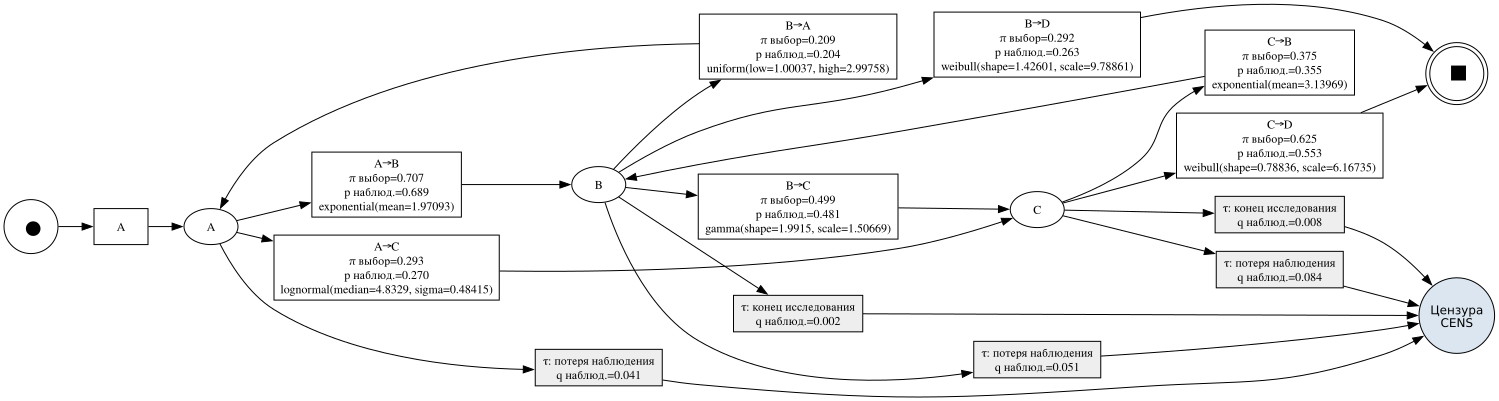

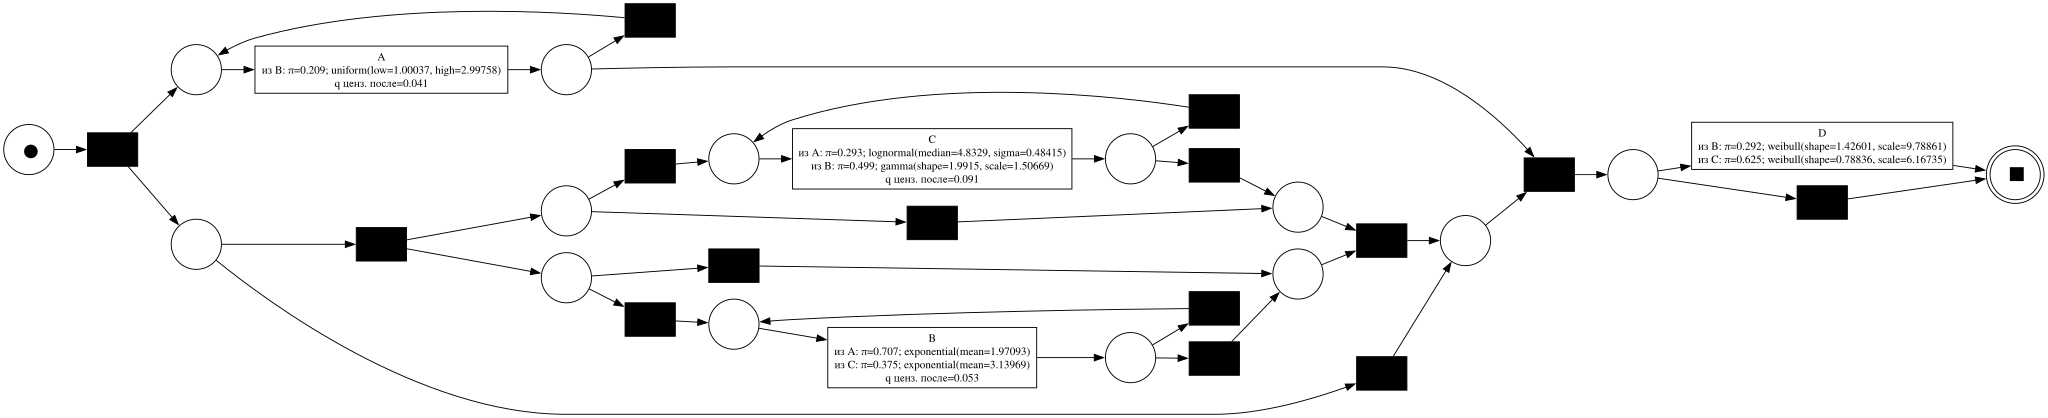

In [13]:
import pm4py
import pm4py.util.constants
from pm4py.visualization.petri_net import visualizer as pn_visualizer

pm4py.util.constants.SHOW_PROGRESS_BAR = False
frame = pm_frame(log)
event_log = pm4py.convert_to_event_log(frame)
censor_probabilities = censoring_summary(intervals)
print(f"Цензурированные трассы: {(cases.event == 0).mean():.1%}; "
      f"потеря: {(cases.censor_reason == 'lost').mean():.1%}; "
      f"конец исследования: {(cases.censor_reason == 'study_end').mean():.1%}")
display(censor_probabilities.round(4))
state_net, state_im, state_fm = state_petri_net(intervals, estimates)
im_net, im_im, im_fm = pm4py.discover_petri_net_inductive(event_log)
im_decorations = decorate_inductive(im_net, estimates, censor_probabilities)

state_decorations = {p: dict(label="Цензура\nCENS" if p.name == CENSORED else p.name,
                            color="#dce6f1" if p.name == CENSORED else "white")
                     for p in state_net.places}
for tr in state_net.transitions:
    dist = tr.properties.get("time_distribution")
    reason = tr.properties.get("censor_reason")
    if reason:
        label = "потеря наблюдения" if reason == "lost" else "конец исследования"
        state_decorations[tr] = dict(label=f"τ: {label}\nq наблюд.={tr.properties['observed_probability']:.3f}",
                                     color="#eeeeee")
    elif tr.name != "start":
        choice = tr.properties["choice_probability"]
        label = f"{tr.name}\nπ выбор={choice:.3f}" if choice is not None else f"{tr.name}\nπ не оценена"
        label += f"\np наблюд.={tr.properties['observed_probability']:.3f}"
        if dist:
            label += f"\n{dist_str(dist)}"
        state_decorations[tr] = dict(label=label, color="white")
state_picture = pn_visualizer.apply(state_net, state_im, state_fm,
                                     parameters={"format": "svg", "decorations": state_decorations})
for place in state_net.places:
    if place.name == CENSORED:
        state_picture.node(str(id(place)), label="Цензура\nCENS", xlabel="", shape="circle",
                           fixedsize="false", width="1.05", height="1.05",
                           fontname="DejaVu Sans", fontsize="12")
display(state_picture)
display(pn_visualizer.apply(im_net, im_im, im_fm,
                            parameters={"format": "svg", "decorations": im_decorations}))


### 4.1 Цензурирование и фишка в CENS

Вероятности в таблице выше оцениваются по числу **ожиданий в состоянии**:

$$\widehat q_s = \frac{N_{s,\mathrm{lost}}+N_{s,\mathrm{study\_end}}}{N_{s,\mathrm{visits}}}.$$

Каждый вход в состояние начинает новое ожидание, поэтому одна трасса может
дать несколько наблюдений. Общая доля цензурированных **трасс** и $q_s$
имеют разные знаменатели. Разделение причин позволяет видеть влияние потери
наблюдения и конечного горизонта исследования.

На диаграмме ниже воспроизводим наблюдаемые переходы первой цензурированной
трассы, затем её остановку. Чёрная точка в голубом месте `CENS` — одна фишка
после прекращения наблюдения. Это снимок маркировки; обычная начальная маркировка
модели по-прежнему содержит фишку в `source`.


case_0001: A → B → CENS; причина=lost; наблюдение=1.97 дней


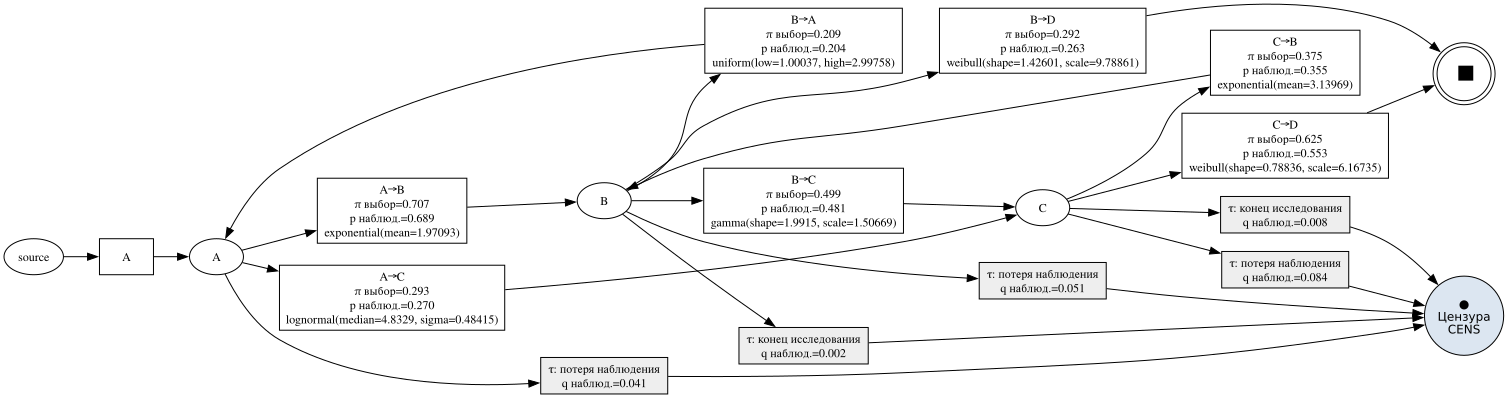

In [14]:
from pm4py.objects.petri_net.obj import Marking
from pm4py.objects.petri_net import semantics

censored_cases = cases.loc[cases.event == 0]
if len(censored_cases):
    example = censored_cases.iloc[0]
    activities = log.loc[log.case_id == example.case_id, "activity"].tolist()
    transitions_by_name = {tr.name: tr for tr in state_net.transitions}
    marking = semantics.execute(transitions_by_name["start"], state_net, state_im)
    for src, dst in zip(activities, activities[1:]):
        marking = semantics.execute(transitions_by_name[f"{src}→{dst}"], state_net, marking)
    stop = transitions_by_name[f"{example.last_state}→{CENSORED}:{example.censor_reason}"]
    marking = semantics.execute(stop, state_net, marking)
    cens_place = next(p for p in state_net.places if p.name == CENSORED)
    assert marking == Marking({cens_place: 1})
    print(f"{example.case_id}: {' → '.join(activities)} → CENS; "
          f"причина={example.censor_reason}; наблюдение={example.duration:.2f} дней")
    snapshot = pn_visualizer.apply(state_net, marking, state_fm,
                                   parameters={"format": "svg", "decorations": state_decorations})
    snapshot.node(str(id(cens_place)), label="●\nЦензура\nCENS", xlabel="", shape="circle",
                  fixedsize="false", width="1.1", height="1.1",
                  fontname="DejaVu Sans", fontsize="12")
    display(snapshot)
else:
    print("В этой выборке цензурированных трасс нет: снимок CENS не строится.")


### 4.2 Схема состояний с отдельной цензурой

Упрощённая схема показывает состояния `A`, `B`, `C`, `D` и отдельное поглощающее
состояние **«Цензура (CENS)»**. Это схема переходов между состояниями, дополняющая
сеть Петри выше. Все подписи — наблюдаемые вероятности **за одно ожидание**:
обычный выход `p наблюд.` и прекращение наблюдения `q`. Сумма выходов из состояния
равна единице. На стрелке в цензуру отдельно указаны доли `lost` и `study_end`.
Общая доля цензурированных трасс приведена в подписи к рисунку.


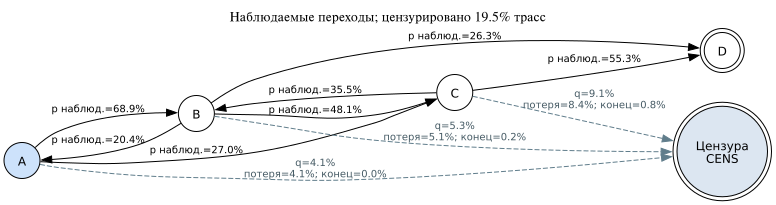

In [15]:
import graphviz

notebook_dir = Path.cwd() if Path("stochastic_petri_net.ipynb").exists() else Path.cwd() / "notebooks"
figure_dir = notebook_dir / "output" / "time_estimation" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

(figure_dir / "estimated_petri_net.png").write_bytes(state_picture.pipe(format="png"))
(figure_dir / "estimated_petri_net.svg").write_bytes(state_picture.pipe(format="svg"))
if len(censored_cases):
    (figure_dir / "censored_marking.png").write_bytes(snapshot.pipe(format="png"))
    (figure_dir / "censored_marking.svg").write_bytes(snapshot.pipe(format="svg"))

state_graph = graphviz.Digraph(graph_attr={"rankdir": "LR", "labelloc": "t", "fontsize": "14"},
                               node_attr={"fontname": "DejaVu Sans", "fontsize": "12"},
                               edge_attr={"fontname": "DejaVu Sans", "fontsize": "10"})
observed_states = sorted(set(intervals.src) | set(intervals.loc[intervals.observed, "dst"]))
for state in observed_states:
    state_graph.node(state, label=state, shape="doublecircle" if state == TERMINAL else "circle",
                     style="filled", fillcolor="#cde2fb" if state == START else "white")
state_graph.node(CENSORED, label="Цензура\nCENS", shape="doublecircle", style="filled", fillcolor="#dce6f1")
visits = censor_probabilities.set_index("src")
counts = intervals.loc[intervals.observed].groupby(["src", "dst"]).size()
for (src, dst), count in counts.items():
    probability = count / visits.loc[src, "n_visits"]
    state_graph.edge(src, dst, label=f"p наблюд.={probability:.1%}")
for src, row in visits.iterrows():
    if row.q_censored > 0:
        label = f"q={row.q_censored:.1%}\nпотеря={row.q_lost:.1%}; конец={row.q_study_end:.1%}"
        state_graph.edge(src, CENSORED, label=label, style="dashed", color="#607d8b", fontcolor="#455a64")
state_graph.attr(label=f"Наблюдаемые переходы; цензурировано {(cases.event == 0).mean():.1%} трасс")
(figure_dir / "observed_states_with_censoring.svg").write_bytes(state_graph.pipe(format="svg"))
(figure_dir / "observed_states_with_censoring.png").write_bytes(state_graph.pipe(format="png"))
display(state_graph)


### 4.3 Наблюдаемые времена и восстановленные распределения

Гистограмма показывает завершённые интервалы, отобранные цензурированием.
Поэтому скорректированная плотность исходного времени может не совпадать с гистограммой.
Сравнение с истинной плотностью здесь возможно благодаря синтетическим данным.


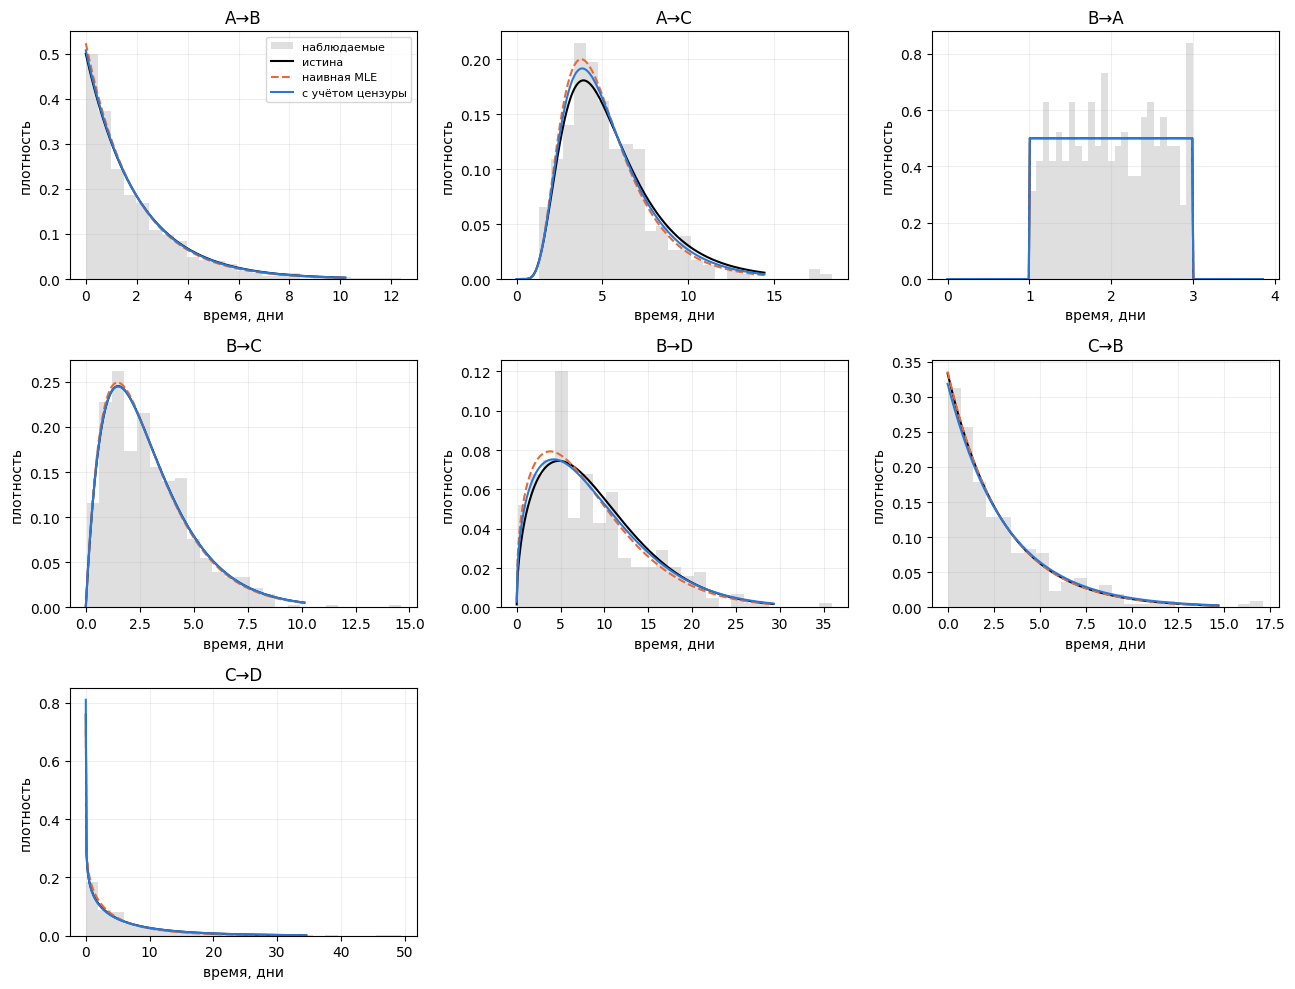

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
lookup = {(t["src"], t["dst"]): t for t in estimates}
naive_lookup = {(t["src"], t["dst"]): t for t in naive_estimates}
for ax, (edge, target) in zip(axes.flat, TRUTH.items()):
    observed = intervals.loc[intervals.observed & (intervals.src == edge[0]) &
                             (intervals.dst == edge[1]), "duration"]
    upper = np.quantile(observed, .98) if len(observed) else 20.
    x = np.linspace(.001, upper * 1.3, 300)
    ax.hist(observed, bins=25, density=True, alpha=.25, color="gray", label="наблюдаемые")
    for label, dist, color, style in [
        ("истина", target["dist"], "black", "-"),
        ("наивная MLE", naive_lookup[edge]["dist"] if edge in naive_lookup else None, "#eb6834", "--"),
        ("с учётом цензуры", lookup[edge]["dist"] if edge in lookup else None, "#2a78d6", "-")]:
        if dist is not None:
            rv, args, kwargs = scipy_args(dist)
            ax.plot(x, rv.pdf(x, *args, **kwargs), color=color, ls=style, label=label)
    ax.set(title=target["name"], xlabel="время, дни", ylabel="плотность")
    ax.grid(alpha=.2)
for ax in axes.flat[len(TRUTH):]:
    ax.set_visible(False)
axes.flat[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(figure_dir / "transition_density.png", dpi=160, bbox_inches="tight")
plt.show()


### 4.4 Функции распределения и выживания времён переходов

Для каждого перехода показываем функцию распределения $F_{sd}(t)=P(T_{sd}\le t)$
и функцию выживания $S_{sd}(t)=P(T_{sd}>t)=1-F_{sd}(t)$. «Выживание» здесь означает,
что выбранный переход ещё не завершился за $t$ дней. Плотности $f_{sd}(t)$ приведены
на предыдущем рисунке.

Чёрная линия — истина, оранжевая — наивная оценка, синяя — оценка с учётом цензуры.
Сравниваются исходные длительности обычных переходов до отбора цензурированием.
У последнего цензурированного интервала направление неизвестно, поэтому отдельную
эмпирическую кривую Каплана–Майера для каждого ребра не строим.


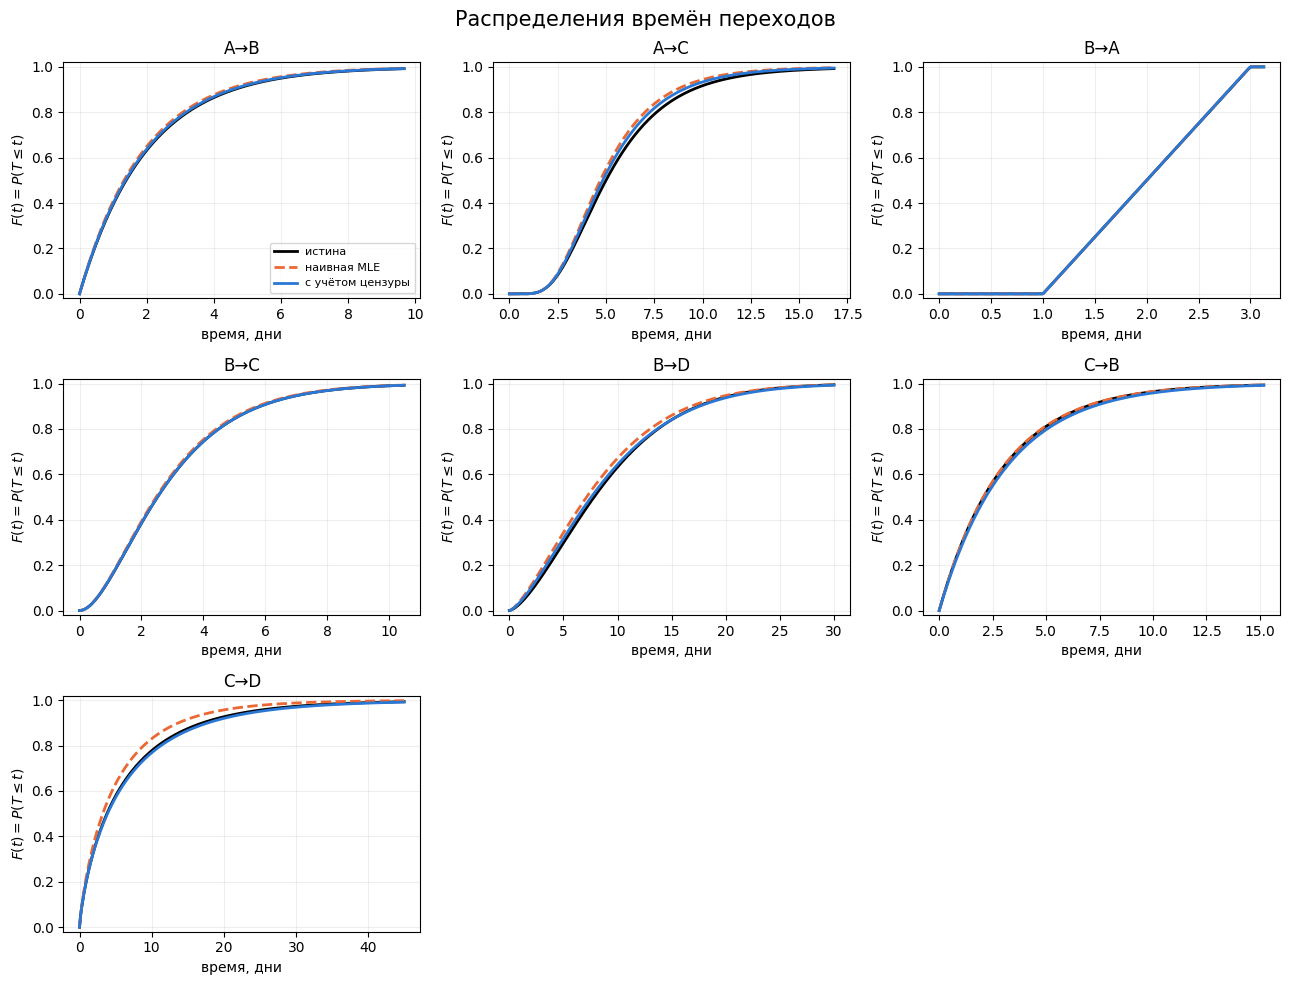

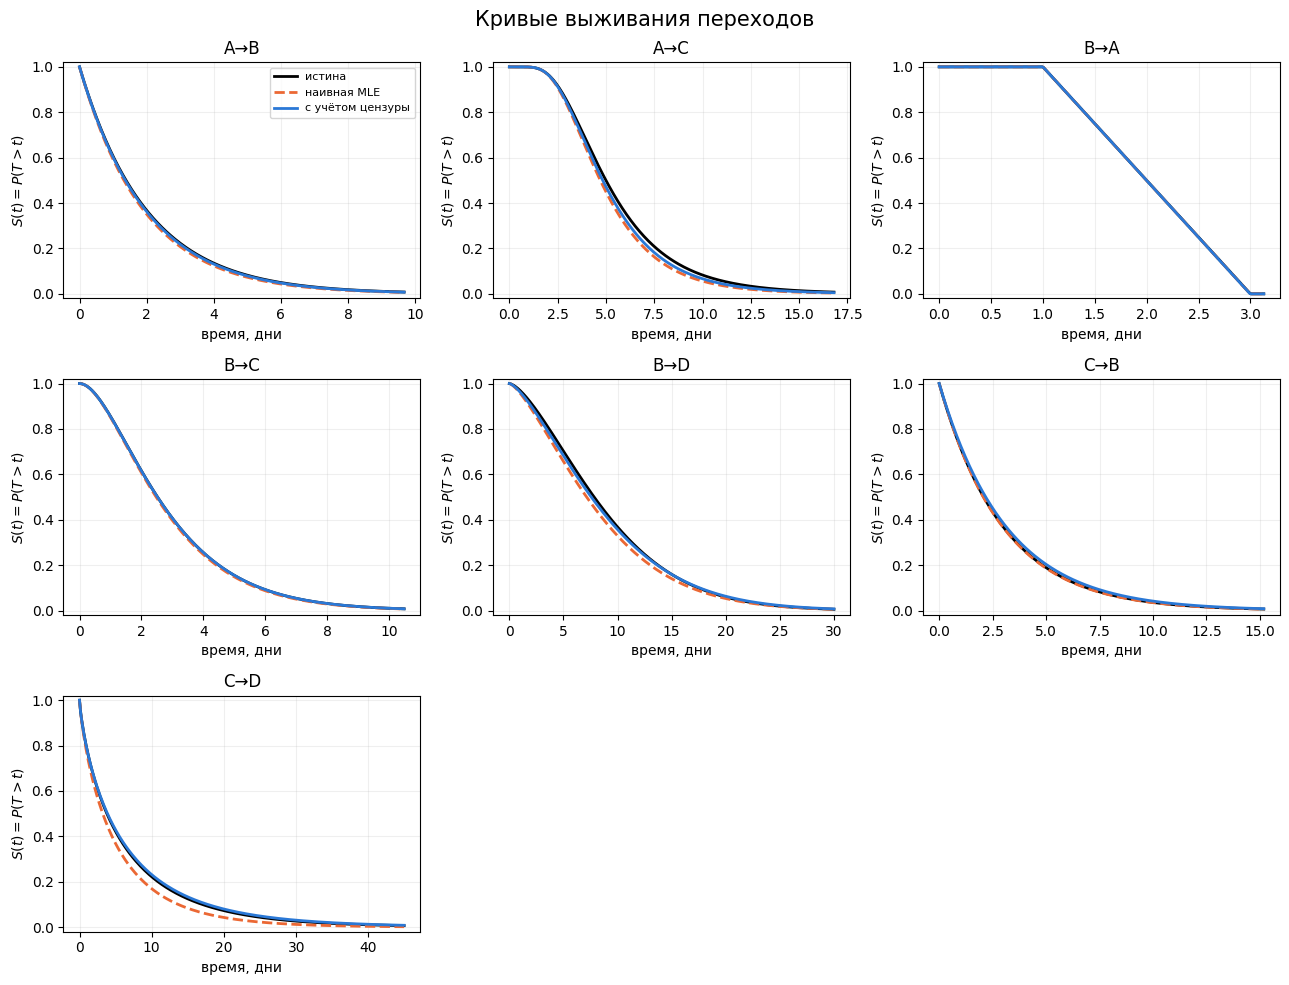

In [17]:
transition_curve_rows = []
for edge, target in TRUTH.items():
    distributions = [
        ("истина", target["dist"]),
        ("наивная MLE", naive_lookup[edge]["dist"] if edge in naive_lookup else None),
        ("с учётом цензуры", lookup[edge]["dist"] if edge in lookup else None),
    ]
    upper = max(rv.ppf(.99, *args, **kwargs) for rv, args, kwargs in
                [scipy_args(dist) for _, dist in distributions if dist is not None])
    grid = np.linspace(0, upper * 1.05, 300)
    for label, dist in distributions:
        if dist is None:
            continue
        rv, args, kwargs = scipy_args(dist)
        cdf = rv.cdf(grid, *args, **kwargs)
        survival = rv.sf(grid, *args, **kwargs)
        assert np.allclose(cdf + survival, 1.)
        transition_curve_rows.extend(dict(transition=target["name"], model=label, time_days=float(t),
                                          cdf=float(f), survival=float(s))
                                     for t, f, s in zip(grid, cdf, survival))
transition_curves = pd.DataFrame(transition_curve_rows)
curve_styles = [("истина", "black", "-"), ("наивная MLE", "#eb6834", "--"),
                ("с учётом цензуры", "#2a78d6", "-")]
for metric, title, ylabel in [
    ("cdf", "Распределения времён переходов", r"$F(t)=P(T\leq t)$"),
    ("survival", "Кривые выживания переходов", r"$S(t)=P(T>t)$"),
]:
    fig, axes = plt.subplots(3, 3, figsize=(13, 10))
    for ax, target in zip(axes.flat, TRUTH.values()):
        for label, color, style in curve_styles:
            data = transition_curves[(transition_curves.transition == target["name"]) &
                                     (transition_curves.model == label)]
            if len(data):
                ax.plot(data.time_days, data[metric], color=color, ls=style, lw=2, label=label)
        ax.set(title=target["name"], xlabel="время, дни", ylabel=ylabel, ylim=(-.02, 1.02))
        ax.grid(alpha=.2)
    for ax in axes.flat[len(TRUTH):]:
        ax.set_visible(False)
    axes.flat[0].legend(fontsize=8)
    fig.suptitle(title, fontsize=15)
    fig.tight_layout()
    fig.savefig(figure_dir / f"transition_{metric}.png", dpi=160, bbox_inches="tight")
    plt.show()


### 4.5 Общее время до D: плотность, распределение и выживание

Теперь $T_D$ — время всего процесса от входа в `A` до первого достижения `D`,
включая все повторные прохождения петель. Для истинной и обеих восстановленных
моделей генерируем по 10 000 новых трасс **без прекращения наблюдения**. Для оценки
параметров эти трассы не используются. Вероятности направления — `π выбор`,
а не наблюдаемые частоты с учётом цензуры.

По симуляциям показываем плотность, $F_D(t)=P(T_D\le t)$ и $S_D(t)=P(T_D>t)$.
Дополнительно строим Каплана–Майера по исходным 1000 наблюдаемым трассам,
используя `cases.duration` и `cases.event`. Потеря наблюдения и конец исследования
остаются цензурой; посещение `CENS` не считается достижением `D`.

Каплан–Майер применим при независимом цензурировании. В текущем генераторе
интенсивность потери одинакова во всех состояниях, а время входа в исследование
независимо от пути объекта. Эмпирическая кривая показывается только до конца
наблюдаемого диапазона; серая область — время за его пределами. Продолжение
модельных кривых там опирается на принятые семейства распределений.

Плотности получены из гистограмм симуляций. При ограничении оси X длинный хвост
не перенормируется: площадь видимой части может быть меньше единицы.


In [18]:
def kaplan_meier(duration, event):
    duration, event = np.asarray(duration), np.asarray(event)
    times = np.unique(duration[event == 1])
    survival, value = [], 1.
    for t in times:
        n_risk = np.count_nonzero(duration >= t)
        n_events = np.count_nonzero((duration == t) & (event == 1))
        value *= 1 - n_events / n_risk
        survival.append(value)
    return np.r_[0., times], np.r_[1., survival]


def simulate_completion_times(transitions, n_cases, seed, max_steps=10_000):
    """Симуляция до D по переданной модели, без цензуры, с повторными посещениями."""
    rng = np.random.default_rng(seed)
    outgoing = {}
    for transition in transitions:
        outgoing.setdefault(transition["src"], []).append(transition)
    times = np.empty(n_cases)
    for i in range(n_cases):
        state, elapsed = START, 0.
        for _ in range(max_steps):
            candidates = outgoing[state]
            transition = candidates[rng.choice(len(candidates), p=[t["p"] for t in candidates])]
            elapsed += sample_time(transition["dist"], rng)
            state = transition["dst"]
            if state == TERMINAL:
                times[i] = elapsed
                break
        else:
            raise RuntimeError("Превышено max_steps при симуляции восстановленной модели")
    return times


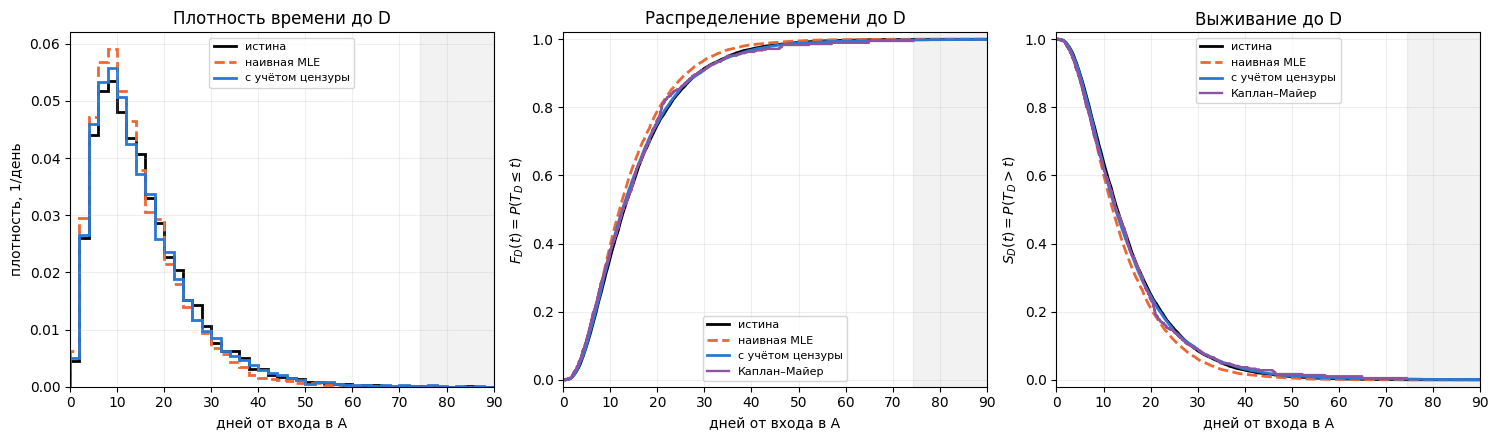

,count,mean,median
model,,,
истина,10000,15.326,12.933
наивная MLE,10000,14.091,11.977
с учётом цензуры,10000,15.266,12.563


In [19]:
COMPLETION_CASES = 10_000
completion_samples = {}
model_specs = [("истина", TRANSITIONS), ("наивная MLE", naive_estimates),
               ("с учётом цензуры", estimates)]
for index, (label, transitions) in enumerate(model_specs):
    recovered_edges = {(t["src"], t["dst"]) for t in transitions}
    if not set(TRUTH).issubset(recovered_edges):
        print(f"{label}: модель неполна, общую кривую до D не строим")
        continue
    completion_samples[label] = simulate_completion_times(transitions, COMPLETION_CASES, seed=87103 + index)

plot_end = max(STUDY_DAYS, max(np.quantile(times, .99) for times in completion_samples.values()))
grid = np.linspace(0, plot_end, 400)
bins = np.linspace(0, plot_end, 46)
km_times, km_survival = kaplan_meier(cases.duration, cases.event)
observed_end = float(cases.duration.max())
km_plot_times = np.r_[km_times, observed_end]
km_plot_survival = np.r_[km_survival, km_survival[-1]]
completion_curve_rows = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for label, color, style in curve_styles:
    if label not in completion_samples:
        continue
    times = completion_samples[label]
    counts, _ = np.histogram(times, bins=bins)
    density = counts / (len(times) * np.diff(bins))
    cdf = np.searchsorted(np.sort(times), grid, side="right") / len(times)
    survival = 1 - cdf
    axes[0].stairs(density, bins, color=color, linestyle=style, linewidth=2, label=label)
    axes[1].plot(grid, cdf, color=color, ls=style, lw=2, label=label)
    axes[2].plot(grid, survival, color=color, ls=style, lw=2, label=label)
    completion_curve_rows.extend(dict(model=label, time_days=float(t), cdf=float(f), survival=float(s))
                                 for t, f, s in zip(grid, cdf, survival))
axes[1].step(km_plot_times, 1 - km_plot_survival, where="post", color="#8c54a1", lw=1.7, label="Каплан–Майер")
axes[2].step(km_plot_times, km_plot_survival, where="post", color="#8c54a1", lw=1.7, label="Каплан–Майер")
for ax, title, ylabel in zip(axes, ["Плотность времени до D", "Распределение времени до D", "Выживание до D"],
                             ["плотность, 1/день", r"$F_D(t)=P(T_D\leq t)$", r"$S_D(t)=P(T_D>t)$"]):
    ax.set(title=title, xlabel="дней от входа в A", ylabel=ylabel, xlim=(0, plot_end))
    ax.axvspan(observed_end, plot_end, color="gray", alpha=.1)
    ax.grid(alpha=.2)
    ax.legend(fontsize=8)
axes[1].set_ylim(-.02, 1.02)
axes[2].set_ylim(-.02, 1.02)
fig.tight_layout()
fig.savefig(figure_dir / "completion_time_curves.png", dpi=160, bbox_inches="tight")
plt.show()

completion_curves = pd.DataFrame(completion_curve_rows)
completion_times = pd.concat([pd.DataFrame(dict(model=label, duration_days=times))
                              for label, times in completion_samples.items()], ignore_index=True)
display(completion_times.groupby("model").duration_days.agg(["count", "mean", "median"]).round(3))


## 5. Качество при разном числе трасс

Для каждого размера $N$ генерируем журнал с одинаковым seed внутри повтора:
первые трассы совпадают, поэтому выборки вложены друг в друга. Генерация каждого
размера выполняется отдельно, чтобы измерить её фактическое время для $N$ трасс.
Разные повторы имеют независимые seed.
Тестовый лог фиксирован, с отдельным seed, и никогда не участвует в обучении.
На всех уровнях $N$ сохраняем горизонт исследования и интенсивность цензуры.

Метрики:

* `edge_recall` — доля истинных пар состояний, обнаруженных в журнале.
  Это структурная полнота сети состояний, а не сравнение дуг workflow-сетей IM.
* `parameter_coverage` — доля истинных переходов с успешной оценкой параметров.
* `parameter_mape` — средняя относительная ошибка **всех** параметров пяти семейств.
* `mean_time_mape` — средняя относительная ошибка $E[T_{sd}]$.
* `probability_mae` — средняя абсолютная ошибка вероятностей выбора.
* `cdf_error` — средний модуль ошибки CDF на 99 истинных квантилях каждого перехода.
* `fitness_all`, `fitness_complete` и `precision_complete` — token-based метрики
  Inductive Miner на независимых трассах; полные трассы заканчиваются в `D`.
* `fit_success_fraction` — доля наблюдаемых источников с успешной оптимизацией.

Ошибки времени и вероятностей приводим только при `parameter_coverage=1`:
не исключаем отсутствующие переходы из среднего, создавая иллюзию хорошего восстановления.
Для IM отдельно показываем число мест, переходов и тихих переходов.
Fitness и precision не измеряют качество временных распределений.


In [20]:
def reconstruction_metrics(intervals, estimates, truth):
    true_edges = set(truth)
    found = set(intervals.loc[intervals.observed, ["src", "dst"]].itertuples(index=False, name=None))
    fitted = {(t["src"], t["dst"]): t for t in estimates}
    metrics = dict(edge_recall=len(found & true_edges) / len(true_edges),
                   parameter_coverage=len(set(fitted) & true_edges) / len(true_edges),
                   parameter_mape=np.nan, mean_time_mape=np.nan, probability_mae=np.nan,
                   cdf_error=np.nan)
    if not true_edges.issubset(fitted):
        return metrics
    parameter_errors, mean_errors, probability_errors, cdf_errors = [], [], [], []
    for edge, target in truth.items():
        estimated = fitted[edge]
        parameter_errors.extend(abs(estimated["dist"][1][name] / value - 1)
                                for name, value in target["dist"][1].items())
        mean_errors.append(abs(mean_time(estimated["dist"]) / mean_time(target["dist"]) - 1))
        probability_errors.append(abs(estimated["p"] - target["p"]))
        rv_true, args_true, kwargs_true = scipy_args(target["dist"])
        rv_est, args_est, kwargs_est = scipy_args(estimated["dist"])
        quantiles = np.linspace(.01, .99, 99)
        grid = rv_true.ppf(quantiles, *args_true, **kwargs_true)
        cdf_errors.append(np.abs(rv_est.cdf(grid, *args_est, **kwargs_est) - quantiles).mean())
    metrics.update(parameter_mape=np.mean(parameter_errors), mean_time_mape=np.mean(mean_errors),
                   probability_mae=np.mean(probability_errors), cdf_error=np.mean(cdf_errors))
    return metrics


def miner_metrics(training_log, test_log, complete_test_log):
    import pm4py
    started = perf_counter()
    net, im, fm = pm4py.discover_petri_net_inductive(training_log)
    discovery_seconds = perf_counter() - started
    started = perf_counter()
    metrics = dict(
        fitness_all=pm4py.fitness_token_based_replay(test_log, net, im, fm)["average_trace_fitness"],
        fitness_complete=pm4py.fitness_token_based_replay(complete_test_log, net, im, fm)["average_trace_fitness"],
        precision_complete=pm4py.precision_token_based_replay(complete_test_log, net, im, fm),
        n_places=len(net.places), n_transitions=len(net.transitions),
        n_silent=sum(t.label is None for t in net.transitions),
    )
    metrics["conformance_seconds"] = perf_counter() - started
    metrics["discovery_seconds"] = discovery_seconds
    return metrics


In [21]:
experiment_started = perf_counter()
test_log, test_cases = generate_log(TEST_CASES, TEST_SEED, STUDY_START, ENROLL_DAYS, STUDY_DAYS)
test_event_log = pm4py.convert_to_event_log(pm_frame(test_log))
complete_ids = set(test_cases.loc[test_cases.event == 1, "case_id"])
complete_test_event_log = pm4py.convert_to_event_log(pm_frame(test_log[test_log.case_id.isin(complete_ids)]))
assert len(complete_test_event_log) > 0
print(f"Независимый тест: {len(test_event_log)} трасс, {len(complete_test_event_log)} полных")

result_rows, parameter_rows, diagnostic_rows, miner_rows, timing_rows = [], [], [], [], []
for repeat in range(N_REPEATS):
    seed = EXPERIMENT_SEED + repeat
    assert seed != TEST_SEED
    for n in TRACE_COUNTS:
        run_started = perf_counter()
        started = perf_counter()
        subset_log, subset_cases = generate_log(n, seed, STUDY_START, ENROLL_DAYS, STUDY_DAYS)
        timing = dict(n_traces=n, repeat=repeat, n_events=len(subset_log),
                      generation_seconds=perf_counter() - started)
        started = perf_counter()
        subset_intervals = make_intervals(subset_log, subset_cases)
        timing["interval_preparation_seconds"] = perf_counter() - started
        started = perf_counter()
        training_event_log = pm4py.convert_to_event_log(pm_frame(subset_log))
        timing["pm_preparation_seconds"] = perf_counter() - started
        discovered = miner_metrics(training_event_log, test_event_log, complete_test_event_log)
        timing["discovery_seconds"] = discovered["discovery_seconds"]
        timing["conformance_seconds"] = discovered["conformance_seconds"]
        miner_rows.append(dict(n_traces=n, repeat=repeat, **discovered))
        for method, corrected in [("naive", False), ("censor_aware", True)]:
            started = perf_counter()
            fitted, fit_diagnostics = estimate_network(subset_intervals, FAMILIES, corrected)
            fit_seconds = perf_counter() - started
            timing[f"{method}_fit_seconds"] = fit_seconds
            metrics = reconstruction_metrics(subset_intervals, fitted, TRUTH)
            result_rows.append(dict(n_traces=n, repeat=repeat, method=method, fit_seconds=fit_seconds,
                                    censored_fraction=1 - subset_cases.event.mean(),
                                    fit_success_fraction=fit_diagnostics.success.mean(), **metrics))
            table = parameter_table(fitted, TRUTH, subset_intervals)
            table["n_traces"], table["repeat"], table["method"] = n, repeat, method
            parameter_rows.extend(table.to_dict("records"))
            diagnostic_rows.extend(fit_diagnostics.assign(n_traces=n, repeat=repeat,
                                                          method=method).to_dict("records"))
        timing["total_seconds"] = perf_counter() - run_started
        timing_rows.append(timing)
    print(f"Повтор {repeat + 1}/{N_REPEATS} завершён", flush=True)

experiment_seconds = perf_counter() - experiment_started
timings = pd.DataFrame(timing_rows)
results = pd.DataFrame(result_rows)
parameter_results = pd.DataFrame(parameter_rows)
fit_diagnostics = pd.DataFrame(diagnostic_rows)
miner_results = pd.DataFrame(miner_rows)
metrics = ["edge_recall", "parameter_coverage", "parameter_mape", "mean_time_mape",
           "probability_mae", "cdf_error", "fit_success_fraction"]
summary = results.groupby(["n_traces", "method"])[metrics].agg(["mean", "std", "count"])
display(summary.round(4))
display(miner_results.groupby("n_traces").mean(numeric_only=True).drop(columns="repeat").round(4))
print("Источников без полной оценки:", int((~fit_diagnostics.success).sum()))
display(fit_diagnostics.loc[~fit_diagnostics.success])


Независимый тест: 2000 трасс, 1530 полных


Повтор 1/5 завершён


Повтор 2/5 завершён


Повтор 3/5 завершён


Повтор 4/5 завершён


Повтор 5/5 завершён


edge_recall               parameter_coverage          \
                             mean     std count               mean     std   
n_traces method                                                              
5        censor_aware      0.9429  0.0782     5             0.2000  0.1917   
         naive             0.9429  0.0782     5             0.2000  0.1917   
10       censor_aware      1.0000  0.0000     5             0.4857  0.1917   
         naive             1.0000  0.0000     5             0.4857  0.1917   
30       censor_aware      1.0000  0.0000     5             1.0000  0.0000   
         naive             1.0000  0.0000     5             1.0000  0.0000   
50       censor_aware      1.0000  0.0000     5             1.0000  0.0000   
         naive             1.0000  0.0000     5             1.0000  0.0000   
100      censor_aware      1.0000  0.0000     5             1.0000  0.0000   
         naive             1.0000  0.0000     5             1.0000  0.0000   
300      censor_aware      1.0000  0.0000     5             1.0000  0.0000   
         naive             1.0000  0.0000     5             1.0000  0.0000   
1000     censor_aware      1.0000  0.0000     5             1.0000  0.0000   
         naive             1.0000  0.0000     5             1.0000  0.0000   
3000     censor_aware      1.0000  0.0000     5             1.0000  0.0000   
         naive             1.0000  0.0000     5             1.0000  0.0000   

                            parameter_mape               mean_time_mape  ...  \
                      count           mean     std count           mean  ...   
n_traces method                                                          ...   
5        censor_aware     5            NaN     NaN     0            NaN  ...   
         naive            5            NaN     NaN     0            NaN  ...   
10       censor_aware     5            NaN     NaN     0            NaN  ...   
         naive            5            NaN     NaN     0            NaN  ...   
30       censor_aware     5         0.2328  0.0750     5         0.2553  ...   
         naive            5         0.2000  0.0593     5         0.1631  ...   
50       censor_aware     5         0.1832  0.0481     5         0.1548  ...   
         naive            5         0.1574  0.0405     5         0.1088  ...   
100      censor_aware     5         0.1062  0.0226     5         0.0897  ...   
         naive            5         0.1011  0.0201     5         0.0867  ...   
300      censor_aware     5         0.0692  0.0181     5         0.0660  ...   
         naive            5         0.0801  0.0106     5         0.0879  ...   
1000     censor_aware     5         0.0287  0.0068     5         0.0283  ...   
         naive            5         0.0476  0.0059     5         0.0617  ...   
3000     censor_aware     5         0.0156  0.0029     5         0.0171  ...   
         naive            5         0.0397  0.0034     5         0.0556  ...   

                            probability_mae               cdf_error          \
                      count            mean     std count      mean     std   
n_traces method                                                               
5        censor_aware     0             NaN     NaN     0       NaN     NaN   
         naive            0             NaN     NaN     0       NaN     NaN   
10       censor_aware     0             NaN     NaN     0       NaN     NaN   
         naive            0             NaN     NaN     0       NaN     NaN   
30       censor_aware     5          0.0834  0.0257     5    0.0733  0.0154   
         naive            5          0.0874  0.0202     5    0.0699  0.0202   
50       censor_aware     5          0.0587  0.0242     5    0.0495  0.0089   
         naive            5          0.0633  0.0218     5    0.0459  0.0084   
100      censor_aware     5          0.0267  0.0120     5    0.0323  0.0078   
         naive            5          0.0323  0.0080     5    0.0320  0

,fitness_all,fitness_complete,precision_complete,n_places,n_transitions,n_silent,conformance_seconds,discovery_seconds
n_traces,,,,,,,,
5,0.9475,0.9614,0.6376,10.0,12.2,8.2,0.0649,0.0012
10,0.9883,0.9910,0.5003,13.0,16.0,12.0,0.0929,0.0011
30,1.0000,1.0000,0.5008,14.2,17.8,13.8,0.0844,0.0013
50,1.0000,1.0000,0.5059,14.6,18.4,14.4,0.0853,0.0013
100,1.0000,1.0000,0.5059,14.6,18.4,14.4,0.1015,0.0014
300,1.0000,1.0000,0.5110,15.0,19.0,15.0,0.0882,0.0020
1000,1.0000,1.0000,0.5110,15.0,19.0,15.0,0.0879,0.0028
3000,1.0000,1.0000,0.5110,15.0,19.0,15.0,0.1078,0.0048


Источников без полной оценки: 36


,src,success,status,n_completed,n_censored,nll,message,at_boundary,n_traces,repeat,method
1,B,False,insufficient_data,7,1,NaN,NaN,NaN,5,0,naive
4,B,False,insufficient_data,7,1,NaN,NaN,NaN,5,0,censor_aware
6,A,False,insufficient_data,12,0,NaN,NaN,NaN,10,0,naive
7,B,False,insufficient_data,12,1,NaN,NaN,NaN,10,0,naive
9,A,False,insufficient_data,12,0,NaN,NaN,NaN,10,0,censor_aware
10,B,False,insufficient_data,12,1,NaN,NaN,NaN,10,0,censor_aware
48,A,False,insufficient_data,4,1,NaN,NaN,NaN,5,1,naive
49,B,False,insufficient_data,7,0,NaN,NaN,NaN,5,1,naive
51,A,False,insufficient_data,4,1,NaN,NaN,NaN,5,1,censor_aware
52,B,False,insufficient_data,7,0,NaN,NaN,NaN,5,1,censor_aware


### 5.1 Кривые качества

Линии — среднее по повторам, полоса — диапазон 10–90% результатов повторов
(**не доверительный интервал**). На оси X число трасс в логарифмическом масштабе.
Пропуски временных ошибок означают неполное восстановление параметров.
Число успешно оценённых повторов видно в таблице `summary` (`count`).


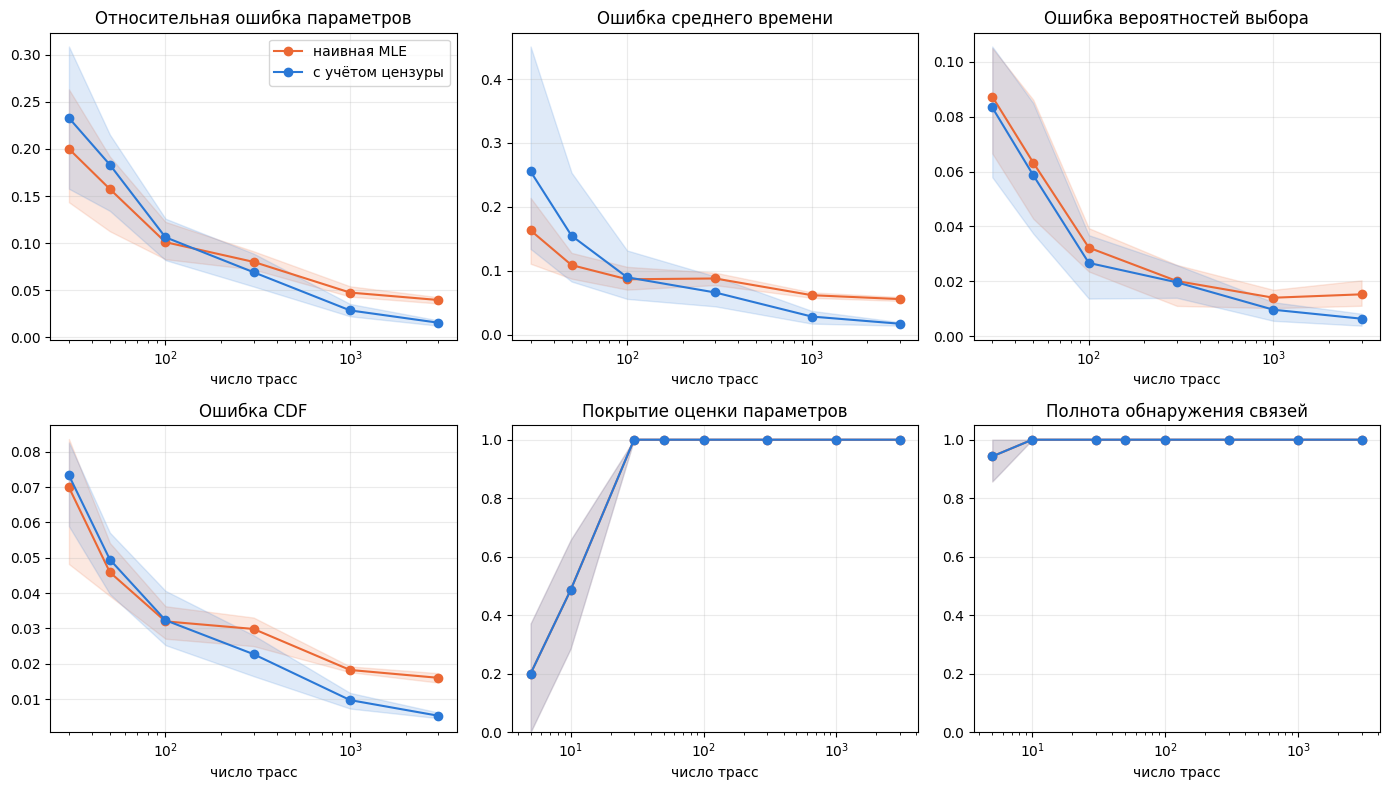

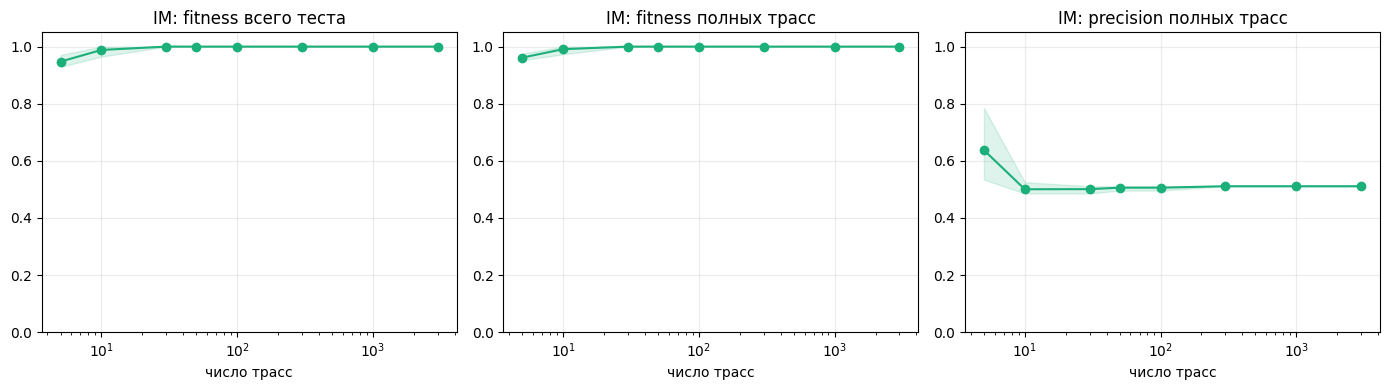

In [22]:
def plot_band(ax, table, metric, label, color):
    grouped = table.groupby("n_traces")[metric]
    x = np.array(sorted(table.n_traces.unique()))
    average = grouped.mean().reindex(x)
    lo, hi = grouped.quantile(.1).reindex(x), grouped.quantile(.9).reindex(x)
    ax.plot(x, average, "o-", label=label, color=color)
    ax.fill_between(x, lo, hi, alpha=.15, color=color)
    ax.set_xscale("log")
    ax.set_xlabel("число трасс")
    ax.grid(alpha=.25)


fig, axes = plt.subplots(2, 3, figsize=(14, 8))
titles = dict(parameter_mape="Относительная ошибка параметров", mean_time_mape="Ошибка среднего времени",
              probability_mae="Ошибка вероятностей выбора", cdf_error="Ошибка CDF",
              parameter_coverage="Покрытие оценки параметров", edge_recall="Полнота обнаружения связей")
for ax, (metric, title) in zip(axes.flat, titles.items()):
    for method, label, color in [("naive", "наивная MLE", "#eb6834"),
                                ("censor_aware", "с учётом цензуры", "#2a78d6")]:
        plot_band(ax, results[results.method == method], metric, label, color)
    ax.set_title(title)
    if metric in ("edge_recall", "parameter_coverage"):
        ax.set_ylim(0, 1.05)
axes.flat[0].legend()
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, title in zip(axes, ["fitness_all", "fitness_complete", "precision_complete"],
                             ["IM: fitness всего теста", "IM: fitness полных трасс", "IM: precision полных трасс"]):
    plot_band(ax, miner_results, metric, "Inductive Miner", "#1baf7a")
    ax.set(title=title, ylim=(0, 1.05))
fig.tight_layout()
plt.show()


### 5.2 Ошибки отдельных переходов и параметров

Общая средняя ошибка может скрывать плохо восстановленное редкое ребро.
Тепловая карта показывает относительную ошибку каждого параметра отдельно
для модели с учётом цензуры. Таблица содержит число доступных оценок по повторам.


mean  count
label      n_traces               
A→B: mean  5         0.2507      1
           10        0.1352      2
           30        0.1240      5
           50        0.1542      5
           100       0.1095      5
...                     ...    ...
C→D: shape 50        0.1014      5
           100       0.0440      5
           300       0.0250      5
           1000      0.0229      5
           3000      0.0132      5

[96 rows x 2 columns]

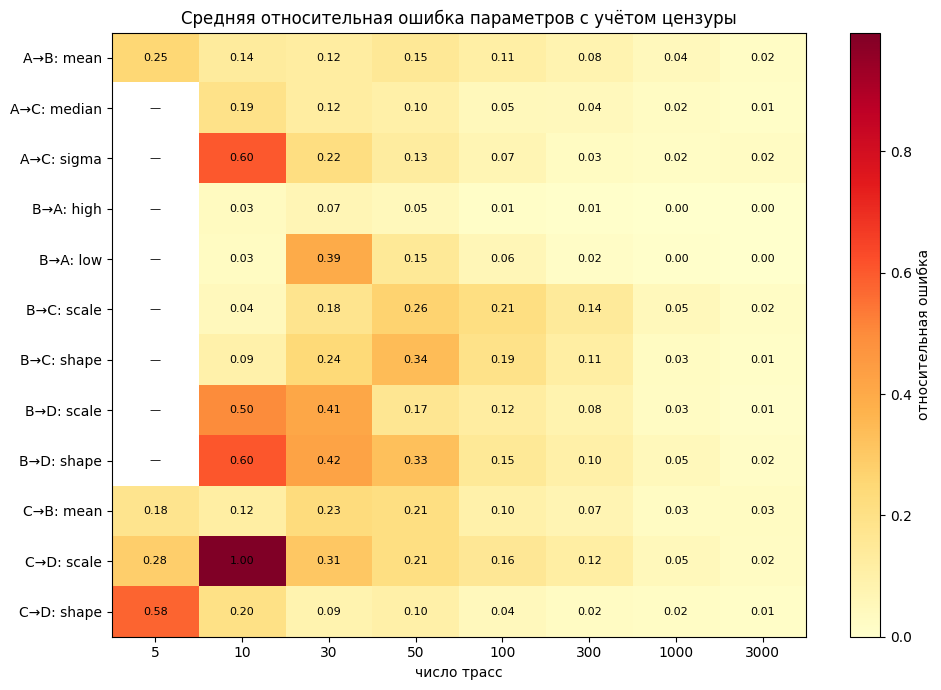

In [23]:
corrected = parameter_results[parameter_results.method == "censor_aware"].copy()
corrected["label"] = corrected["transition"] + ": " + corrected["parameter"]
per_parameter = corrected.groupby(["label", "n_traces"])["relative_error"].agg(["mean", "count"])
display(per_parameter.round(4))
heatmap = corrected.pivot_table(index="label", columns="n_traces", values="relative_error", aggfunc="mean")
fig, ax = plt.subplots(figsize=(10, 7))
image = ax.imshow(heatmap.to_numpy(), aspect="auto", cmap="YlOrRd", vmin=0)
ax.set_xticks(range(len(heatmap.columns)), heatmap.columns)
ax.set_yticks(range(len(heatmap.index)), heatmap.index)
ax.set(xlabel="число трасс", title="Средняя относительная ошибка параметров с учётом цензуры")
for i in range(len(heatmap)):
    for j in range(len(heatmap.columns)):
        value = heatmap.iloc[i, j]
        ax.text(j, i, f"{value:.2f}" if np.isfinite(value) else "—", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="относительная ошибка")
fig.tight_layout()
plt.show()


### 5.3 Время выполнения

Измеряем прошедшее время в секундах через `time.perf_counter()`:

* `generation_seconds` — генерация $N$ трасс и двух таблиц данных;
* `interval_preparation_seconds` — построение завершённых и цензурированных интервалов;
* `pm_preparation_seconds` — преобразование обучающего журнала в формат PM4Py;
* `discovery_seconds` — восстановление структуры Inductive Miner;
* `conformance_seconds` — расчёт fitness и precision на фиксированном тестовом логе;
* `naive_fit_seconds`, `censor_aware_fit_seconds` — оценка вероятностей и параметров;
* `total_seconds` — весь расчёт одного размера $N$ в одном повторе, включая оба
  оценивателя, проверку качества и сбор результатов. Построение графиков сюда не входит.

Таблица показывает среднее, стандартное отклонение и число замеров по пяти повторам.
На графиках линия — среднее, полоса — диапазон 10–90% замеров. Тестовый журнал
всегда имеет 2000 трасс, поэтому время проверки соответствия не является временем
обработки $N$ тестовых трасс. Результаты зависят от компьютера и его текущей нагрузки;
импорт библиотек выполнен до измерений. На малых выборках оцениватель может завершиться
быстро из-за недостатка данных — сопоставляйте время с `parameter_coverage`.

Общее время экспериментальной ячейки включает подготовку независимого тестового
журнала и все повторы, до вывода сводных таблиц. CSV сохраняются в конце ноутбука.


Время экспериментальной ячейки: 31.51 с


generation_seconds               interval_preparation_seconds  \
                       mean     std count                         mean   
n_traces                                                                 
5                    0.0012  0.0001     5                       0.0018   
10                   0.0015  0.0002     5                       0.0016   
30                   0.0035  0.0002     5                       0.0016   
50                   0.0051  0.0004     5                       0.0017   
100                  0.0099  0.0005     5                       0.0018   
300                  0.0287  0.0016     5                       0.0020   
1000                 0.0933  0.0109     5                       0.0024   
3000                 0.2791  0.0274     5                       0.0039   

                       pm_preparation_seconds               discovery_seconds  \
             std count                   mean     std count              mean   
n_traces                                                                        
5         0.0002     5                 0.0051  0.0013     5            0.0012   
10        0.0002     5                 0.0032  0.0003     5            0.0011   
30        0.0001     5                 0.0039  0.0006     5            0.0013   
50        0.0003     5                 0.0041  0.0004     5            0.0013   
100       0.0003     5                 0.0051  0.0004     5            0.0014   
300       0.0003     5                 0.0091  0.0011     5            0.0020   
1000      0.0001     5                 0.0226  0.0009     5            0.0028   
3000      0.0003     5                 0.0839  0.0262     5            0.0048   

          ... conformance_seconds naive_fit_seconds                \
          ...               count              mean     std count   
n_traces  ...                                                       
5         ...                   5            0.0128  0.0107     5   
10        ...                   5            0.0770  0.1012     5   
30        ...                   5            0.2638  0.0254     5   
50        ...                   5            0.2737  0.0296     5   
100       ...                   5            0.2686  0.0264     5   
300       ...                   5            0.2813  0.0271     5   
1000      ...                   5            0.3394  0.0084     5   
3000      ...                   5            0.4541  0.0396     5   

         censor_aware_fit_seconds               total_seconds                
                             mean     std count          mean     std count  
n_traces                                                                     
5                          0.0119  0.0102     5        0.1016  0.0173     5  
10                         0.0990  0.1165     5        0.2792  0.2045     5  
30                         0.4268  0.0686     5        0.7892  0.0800     5  
50                         0.3818  0.0424     5        0.7568  0.0650     5  
100                        0.3984  0.0228     5        0.7908  0.0333     5  
300                        0.4305  0.0314     5        0.8465  0.0270     5  
1000                       0.5188  0.0378     5        1.0722  0.0339     5  
3000                       0.6674  0.0360     5        1.6069  0.0750     5  

[8 rows x 24 columns]

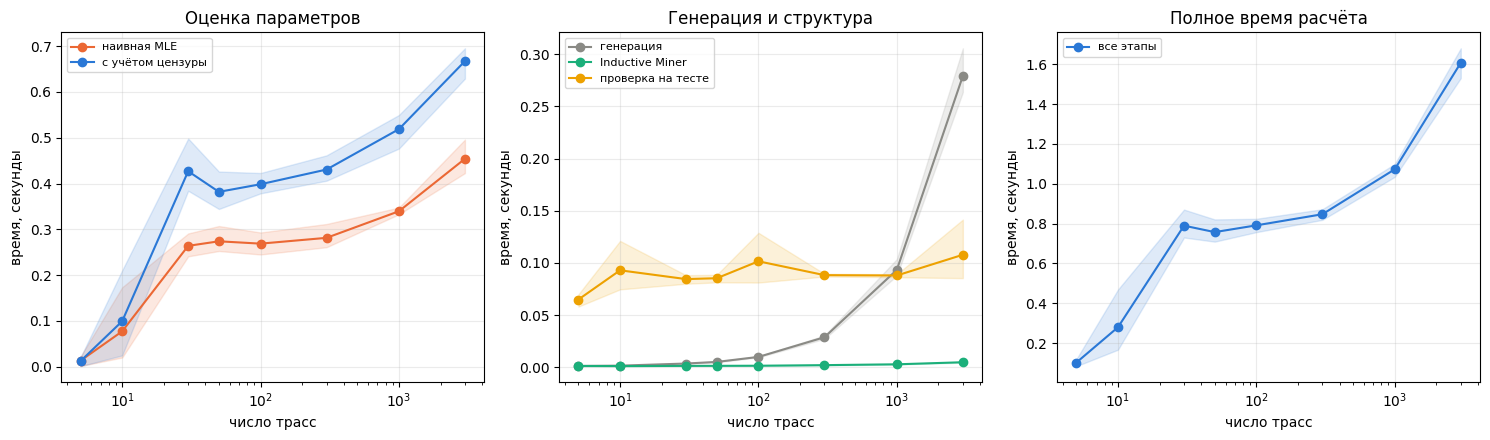

In [24]:
time_columns = ["generation_seconds", "interval_preparation_seconds", "pm_preparation_seconds",
                "discovery_seconds", "conformance_seconds", "naive_fit_seconds",
                "censor_aware_fit_seconds", "total_seconds"]
timing_summary = timings.groupby("n_traces")[time_columns].agg(["mean", "std", "count"])
print(f"Время экспериментальной ячейки: {experiment_seconds:.2f} с")
display(timing_summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for metric, label, color in [
    ("naive_fit_seconds", "наивная MLE", "#eb6834"),
    ("censor_aware_fit_seconds", "с учётом цензуры", "#2a78d6")]:
    plot_band(axes[0], timings, metric, label, color)
for metric, label, color in [
    ("generation_seconds", "генерация", "#8a8a85"),
    ("discovery_seconds", "Inductive Miner", "#1baf7a"),
    ("conformance_seconds", "проверка на тесте", "#eda100")]:
    plot_band(axes[1], timings, metric, label, color)
plot_band(axes[2], timings, "total_seconds", "все этапы", "#2a78d6")
for ax, title in zip(axes, ["Оценка параметров", "Генерация и структура", "Полное время расчёта"]):
    ax.set(title=title, ylabel="время, секунды")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 6. Результаты и ограничения

Последняя ячейка печатает фактические метрики для минимального и максимального $N$.
Не требуем монотонного улучшения в каждом повторе: число событий редких переходов
случайно, а многопараметрическая оценка на малых выборках нестабильна.
При увеличении $N$ наивная оценка может сходиться к смещённым значениям.

Результаты зависят от сети, горизонта и механизма цензурирования. Здесь потеря
наблюдения независима от выбранного времени условно на текущем состоянии.
Если цензура зависит от скрытого времени, использованное правдоподобие неверно.
Сеть с одним токеном не содержит параллелизма; восстановление произвольной
сети Петри и выбор семейства распределения требуют другого эксперимента.
Численные ограничения оптимизатора и результаты `at_boundary` сохраняются
для проверки. У uniform оптимум `high` на наблюдаемом максимуме ожидаем,
если цензура не требует большей верхней границы. Для других параметров
попадание на границу требует отдельного внимания.

Документация методов: [SciPy: MLE и fit](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.fit.html),
[SciPy: logsf](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.logsf.html),
[PM4Py: conformance](https://processintelligence.solutions/app/static/api/2.7.17/api/pm4py.conformance.html).


In [25]:
for n in (min(TRACE_COUNTS), max(TRACE_COUNTS)):
    print(f"\nN = {n}")
    for method in ("naive", "censor_aware"):
        group = results[(results.n_traces == n) & (results.method == method)]
        valid = int(group.parameter_mape.notna().sum())
        if valid:
            print(f"  {method}: полная оценка {valid}/{N_REPEATS}; "
                  f"MAPE параметров={group.parameter_mape.mean():.3f}; "
                  f"MAPE среднего={group.mean_time_mape.mean():.3f}; "
                  f"ошибка CDF={group.cdf_error.mean():.3f}")
        else:
            print(f"  {method}: недостаточно данных для полной оценки во всех {N_REPEATS} повторах")
    miner = miner_results[miner_results.n_traces == n]
    print(f"  IM: fitness полного теста={miner.fitness_complete.mean():.3f}; "
          f"precision={miner.precision_complete.mean():.3f}")

# Каталог относительно ноутбука при запуске из notebooks, либо от корня репозитория.
notebook_dir = Path.cwd() if Path("stochastic_petri_net.ipynb").exists() else Path.cwd() / "notebooks"
out = notebook_dir / "output" / "time_estimation"
out.mkdir(parents=True, exist_ok=True)
results.to_csv(out / "reconstruction_metrics.csv", index=False)
miner_results.to_csv(out / "inductive_metrics.csv", index=False)
parameter_results.to_csv(out / "parameter_estimates.csv", index=False)
fit_diagnostics.to_csv(out / "fit_diagnostics.csv", index=False)
summary.to_csv(out / "summary.csv")
timings.to_csv(out / "execution_times.csv", index=False)
timing_summary.to_csv(out / "execution_time_summary.csv")
censor_probabilities.to_csv(out / "censoring_probabilities.csv", index=False)
transition_curves.to_csv(out / "transition_curves.csv", index=False)
completion_curves.to_csv(out / "completion_curves.csv", index=False)
completion_times.to_csv(out / "completion_times.csv", index=False)
print("Рисунки сохранены:", figure_dir.resolve())
print("\nТаблицы сохранены:", out.resolve())



N = 5
  naive: недостаточно данных для полной оценки во всех 5 повторах
  censor_aware: недостаточно данных для полной оценки во всех 5 повторах
  IM: fitness полного теста=0.961; precision=0.638

N = 3000
  naive: полная оценка 5/5; MAPE параметров=0.040; MAPE среднего=0.056; ошибка CDF=0.016
  censor_aware: полная оценка 5/5; MAPE параметров=0.016; MAPE среднего=0.017; ошибка CDF=0.005
  IM: fitness полного теста=1.000; precision=0.511
Рисунки сохранены: /Users/dimonzhi/Documents/proga/SurvivalProcessMining/notebooks/output/time_estimation/figures

Таблицы сохранены: /Users/dimonzhi/Documents/proga/SurvivalProcessMining/notebooks/output/time_estimation
